# SentinAI Data Quality & EDA Notebook

## Section 1: Data Loading

Load all data sources and validate basic structure.

In [1]:
import os
os.chdir('/home/dan/project/sentinAI')
print('Working directory:', os.getcwd())

Working directory: /home/dan/project/sentinAI


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import json
import os
from scipy import stats
import networkx as nx

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

CONFIG = {
    'seed': 42,
    'n_customers': 1000,
    'n_transactions': 10000,
    'data_dir': 'data',
    'profiles_path': 'data/bronze/customers/customer_profiles_complete.csv',
    'tx_path': 'data/detailed_transactions.csv',
    'truth_path': 'data/aml_ground_truth.csv',
    'temporal_path': 'data/temporal_features.csv'
}

print('Configuration loaded')
print(json.dumps(CONFIG, indent=2))

Configuration loaded
{
  "seed": 42,
  "n_customers": 1000,
  "n_transactions": 10000,
  "data_dir": "data",
  "profiles_path": "data/bronze/customers/customer_profiles_complete.csv",
  "tx_path": "data/detailed_transactions.csv",
  "truth_path": "data/aml_ground_truth.csv",
  "temporal_path": "data/temporal_features.csv"
}


In [3]:
# Load Customer Profiles
df_profiles = pd.read_csv(CONFIG['profiles_path'])
print('\n=== CUSTOMER PROFILES ===')
print(f'Shape: {df_profiles.shape}')
print(f'\nColumns & Types:\n{df_profiles.dtypes}')
print(f'\nMissing Values (%):\n{(df_profiles.isnull().sum() / len(df_profiles) * 100).round(2)}')
print(f'\nDuplicate Rows: {df_profiles.duplicated().sum()}')
print(f'\nFirst 5 rows:')
df_profiles.head()


=== CUSTOMER PROFILES ===
Shape: (1000, 13)

Columns & Types:
customer_id                        object
gender                             object
age                                 int64
county                             object
urban_rural_classification         object
kyc_tier                           object
max_transaction_limit_kes         float64
max_balance_limit_kes             float64
betting_platform_flag                bool
international_transaction_flag       bool
account_age_days                    int64
initial_balance_kes               float64
archetype                          object
dtype: object

Missing Values (%):
customer_id                       0.0
gender                            0.0
age                               0.0
county                            0.0
urban_rural_classification        0.0
kyc_tier                          0.0
max_transaction_limit_kes         0.0
max_balance_limit_kes             0.0
betting_platform_flag             0.0
international_

,customer_id,gender,age,county,urban_rural_classification,kyc_tier,max_transaction_limit_kes,max_balance_limit_kes,betting_platform_flag,international_transaction_flag,account_age_days,initial_balance_kes,archetype
0,CUST_000000,Female,24,Nairobi,urban,tier_2,150000.0,500000.0,False,False,339,253490.054822,retail_heavy
1,CUST_000001,Male,41,Kiambu,semi_urban,tier_2,150000.0,500000.0,False,False,33,184763.020743,retail_standard
2,CUST_000002,Female,32,Kiambu,semi_urban,tier_1,70000.0,300000.0,False,False,87,133658.635044,micro_merchant
3,CUST_000003,Female,29,Kiambu,semi_urban,tier_2,150000.0,500000.0,False,False,240,122264.184131,retail_standard
4,CUST_000004,Male,30,Kisumu,urban,tier_3,250000.0,500000.0,False,False,211,475000.000000,retail_standard


In [4]:
# Load Transactions
df_transactions = pd.read_csv(CONFIG['tx_path'])
print('\n=== TRANSACTIONS ===')
print(f'Shape: {df_transactions.shape}')
print(f'\nColumns & Types:\n{df_transactions.dtypes}')
print(f'\nMissing Values (%):\n{(df_transactions.isnull().sum() / len(df_transactions) * 100).round(2)}')
print(f'\nDuplicate Rows: {df_transactions.duplicated().sum()}')
print(f'\nFirst 5 rows:')
df_transactions.head()


=== TRANSACTIONS ===
Shape: (10000, 20)

Columns & Types:
transaction_id       object
customer_id          object
counterparty         object
transaction_type     object
amount              float64
direction            object
timestamp            object
paid_in             float64
paid_out            float64
balance             float64
tier                  int64
hour                  int64
day_of_week           int64
month                 int64
is_weekend             bool
is_night               bool
is_betting             bool
is_international       bool
is_kadogo              bool
balance_after       float64
dtype: object

Missing Values (%):
transaction_id      0.0
customer_id         0.0
counterparty        0.0
transaction_type    0.0
amount              0.0
direction           0.0
timestamp           0.0
paid_in             0.0
paid_out            0.0
balance             0.0
tier                0.0
hour                0.0
day_of_week         0.0
month               0.0
is_weekend

,transaction_id,customer_id,counterparty,transaction_type,amount,direction,timestamp,paid_in,paid_out,balance,tier,hour,day_of_week,month,is_weekend,is_night,is_betting,is_international,is_kadogo,balance_after
0,TXN_0000000000,CUST_000111,Agent-556,Agent Deposit,101.88,inflow,2024-07-01T02:25:29.381360+00:00,101.88,0.00,173518.22,1,2,0,7,False,True,False,False,False,173518.22
1,TXN_0000000001,CUST_000646,Paybill-488750,Lipa Na M-PESA (Paybill),25.79,outflow,2024-07-01T03:43:02.195651+00:00,0.00,25.79,260502.60,2,3,0,7,False,True,False,False,True,260502.60
2,TXN_0000000002,CUST_000124,User-24568,Send Money,1695.69,outflow,2024-07-01T04:03:23.343887+00:00,0.00,1695.69,197935.02,2,4,0,7,False,True,False,False,False,197935.02
3,TXN_0000000003,CUST_000165,User-63866,Received Money,5231.42,inflow,2024-07-01T04:26:07.760025+00:00,5231.42,0.00,108251.79,1,4,0,7,False,True,False,False,False,108251.79
4,TXN_0000000004,CUST_000030,Fuliza,Others,208.93,inflow,2024-07-01T05:42:23.873780+00:00,208.93,0.00,216439.47,2,5,0,7,False,True,False,False,False,216439.47


In [5]:
# Load AML Ground Truth
df_truth = pd.read_csv(CONFIG['truth_path'])
print('\n=== AML GROUND TRUTH ===')
print(f'Shape: {df_truth.shape}')
print(f'\nColumns & Types:\n{df_truth.dtypes}')
print(f'\nMissing Values (%):\n{(df_truth.isnull().sum() / len(df_truth) * 100).round(2)}')
print(f'\nDuplicate Rows: {df_truth.duplicated().sum()}')
print(f'\nValue Counts (is_launderer):\n{df_truth["is_launderer"].value_counts()}')
print(f'\nAML Scenarios:\n{df_truth["aml_scenario"].value_counts()}')
print(f'\nFirst 5 rows:')
df_truth.head()


=== AML GROUND TRUTH ===
Shape: (1000, 3)

Columns & Types:
user_id         object
is_launderer      bool
aml_scenario    object
dtype: object

Missing Values (%):
user_id         0.0
is_launderer    0.0
aml_scenario    0.0
dtype: float64

Duplicate Rows: 0

Value Counts (is_launderer):
is_launderer
False    980
True      20
Name: count, dtype: int64

AML Scenarios:
aml_scenario
none                980
smurfing              8
layering              6
mule_account          4
circular_trading      2
Name: count, dtype: int64

First 5 rows:


,user_id,is_launderer,aml_scenario
0,CUST_000022,False,none
1,CUST_000015,False,none
2,CUST_000482,False,none
3,CUST_000850,False,none
4,CUST_000576,False,none


In [6]:
# Load Temporal Features
df_temporal = pd.read_csv(CONFIG['temporal_path'])
print('\n=== TEMPORAL FEATURES ===')
print(f'Shape: {df_temporal.shape}')
print(f'\nColumns & Types:\n{df_temporal.dtypes}')
print(f'\nMissing Values (%):\n{(df_temporal.isnull().sum() / len(df_temporal) * 100).round(2)}')
print(f'\nDuplicate Rows: {df_temporal.duplicated().sum()}')
print(f'\nFirst 5 rows:')
df_temporal.head()


=== TEMPORAL FEATURES ===
Shape: (1000, 24)

Columns & Types:
user_id                    object
dominant_hour               int64
dominant_hour_pct         float64
has_consistent_pattern       bool
morning_pct               float64
lunch_pct                 float64
evening_pct               float64
hourly_entropy            float64
weekend_ratio             float64
weekend_tx_count            int64
weekday_tx_count            int64
weekend_anomaly              bool
month_end_tx_ratio        float64
salary_receipt_ratio      float64
school_fee_total          float64
school_fee_flag              bool
roll_1h_count               int64
roll_24h_count              int64
roll_24h_volume           float64
roll_7d_avg_value         float64
roll_30d_volume           float64
roll_30d_count              int64
total_tx_count              int64
avg_tx_value              float64
dtype: object

Missing Values (%):
user_id                   0.0
dominant_hour             0.0
dominant_hour_pct         

,user_id,dominant_hour,dominant_hour_pct,has_consistent_pattern,morning_pct,lunch_pct,evening_pct,hourly_entropy,weekend_ratio,weekend_tx_count,weekday_tx_count,weekend_anomaly,month_end_tx_ratio,salary_receipt_ratio,school_fee_total,school_fee_flag,roll_1h_count,roll_24h_count,roll_24h_volume,roll_7d_avg_value,roll_30d_volume,roll_30d_count,total_tx_count,avg_tx_value
0,CUST_000239,15,28.5714,False,0.0,0.0000,14.2857,2.2359,0.0000,0,7,False,0.0000,0.0000,0.0,False,1,2,2001.21,3192.26,17339.13,7,7,2477.02
1,CUST_000143,9,25.0000,False,0.0,16.6667,16.6667,3.0221,0.1667,2,10,False,0.0000,0.0000,0.0,False,1,1,1388.09,843.09,13076.56,12,12,1089.71
2,CUST_000477,21,22.2222,False,0.0,0.0000,11.1111,2.7255,0.1111,1,8,False,0.2222,0.1111,0.0,False,1,2,9083.32,2613.87,32506.60,9,9,3611.84
3,CUST_000339,12,16.6667,False,0.0,16.6667,22.2222,3.0441,0.1111,2,16,False,0.1111,0.0556,0.0,False,1,1,423.67,867.50,26662.72,18,18,1481.26
4,CUST_000165,18,22.2222,False,0.0,0.0000,22.2222,2.7255,0.2222,2,7,False,0.1111,0.1111,0.0,False,1,1,832.08,772.94,38150.97,9,9,4239.00


In [7]:
# Cross-validation: Check row counts match
print('\n=== VALIDATION: ROW COUNT ALIGNMENT ===')
print(f'Profiles: {len(df_profiles)}')
print(f'Transactions: {len(df_transactions)}')
print(f'Ground Truth: {len(df_truth)}')
print(f'Temporal: {len(df_temporal)}')

print(f'\nUnique customers in profiles: {df_profiles["customer_id"].nunique()}')
print(f'Unique customers in transactions: {df_transactions["customer_id"].nunique()}')
print(f'Unique users in ground truth: {df_truth["user_id"].nunique()}')
print(f'Unique users in temporal: {df_temporal["user_id"].nunique()}')


=== VALIDATION: ROW COUNT ALIGNMENT ===
Profiles: 1000
Transactions: 10000
Ground Truth: 1000
Temporal: 1000

Unique customers in profiles: 1000
Unique customers in transactions: 1000
Unique users in ground truth: 1000
Unique users in temporal: 1000


In [8]:
# Parse transaction timestamp
df_transactions['timestamp'] = pd.to_datetime(df_transactions['timestamp'])
print(f'\n=== TRANSACTION TIME RANGE ===')
print(f'Min: {df_transactions["timestamp"].min()}')
print(f'Max: {df_transactions["timestamp"].max()}')
print(f'Days covered: {(df_transactions["timestamp"].max() - df_transactions["timestamp"].min()).days}')


=== TRANSACTION TIME RANGE ===
Min: 2024-07-01 02:25:29.381360+00:00
Max: 2024-07-26 17:42:13.059927+00:00
Days covered: 25


## Section 2: Customer Profile Validation

Analyze customer demographics, tiers, archetypes, and flags.


=== TIER DISTRIBUTION ===
kyc_tier
tier_1    60.7
tier_2    29.0
tier_3    10.3
Name: proportion, dtype: float64


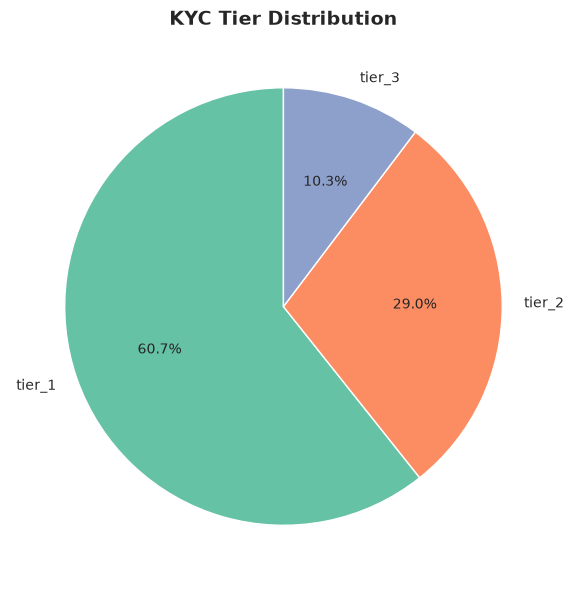


Validation:
✅ tier_1: 60.7% (expected ~60%, diff=0.7%)
✅ tier_2: 29.0% (expected ~30%, diff=1.0%)
✅ tier_3: 10.3% (expected ~10%, diff=0.3%)


In [9]:
# Tier Distribution
print('\n=== TIER DISTRIBUTION ===')
tier_counts = df_profiles['kyc_tier'].value_counts(normalize=True) * 100
print(tier_counts.round(2))

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.Set2(range(len(tier_counts)))
wedges, texts, autotexts = ax.pie(tier_counts.values, labels=tier_counts.index, 
                                    autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('KYC Tier Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Validate expected distribution (60/30/10 ±5%)
print('\nValidation:')
for tier, pct in tier_counts.items():
    if tier == 'tier_1':
        expected = 60
    elif tier == 'tier_2':
        expected = 30
    else:
        expected = 10
    diff = abs(pct - expected)
    status = '✅' if diff <= 5 else '⚠️'
    print(f'{status} {tier}: {pct:.1f}% (expected ~{expected}%, diff={diff:.1f}%)')


=== AGE STATISTICS ===
Mean: 31.3
Median: 31.0
Min: 18
Max: 61


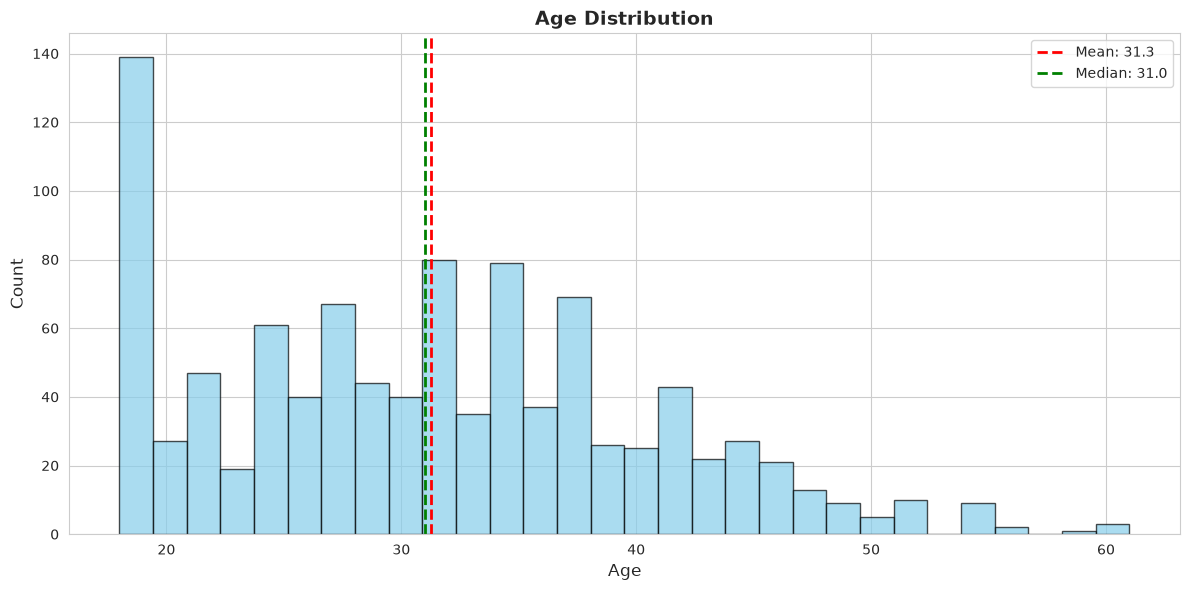

In [10]:
# Age Distribution
print('\n=== AGE STATISTICS ===')
print(f'Mean: {df_profiles["age"].mean():.1f}')
print(f'Median: {df_profiles["age"].median():.1f}')
print(f'Min: {df_profiles["age"].min()}')
print(f'Max: {df_profiles["age"].max()}')

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df_profiles['age'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax.axvline(df_profiles['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_profiles["age"].mean():.1f}')
ax.axvline(df_profiles['age'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_profiles["age"].median():.1f}')
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Age Distribution', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


=== GENDER DISTRIBUTION ===
gender
Female    50.7
Male      49.3
Name: proportion, dtype: float64


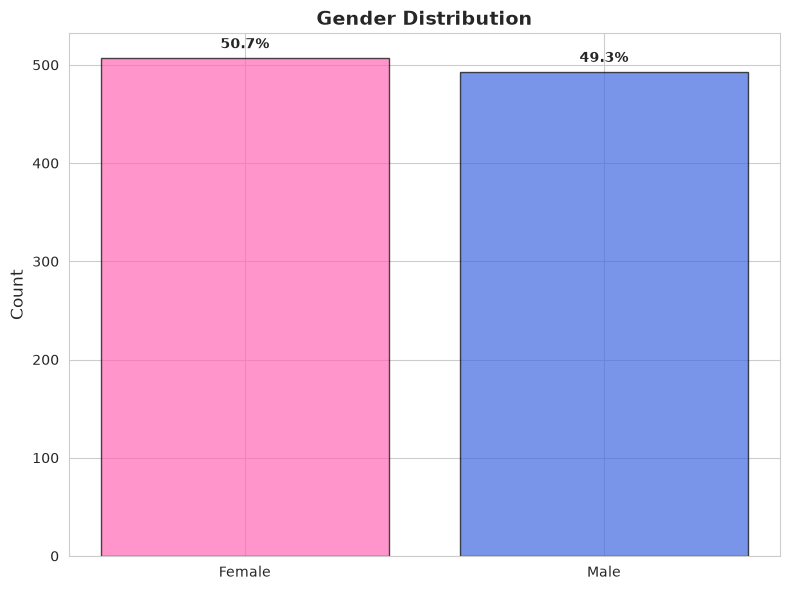

In [11]:
# Gender Distribution
print('\n=== GENDER DISTRIBUTION ===')
gender_counts = df_profiles['gender'].value_counts()
gender_pct = df_profiles['gender'].value_counts(normalize=True) * 100
print(gender_pct.round(2))

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#FF69B4', '#4169E1']
ax.bar(gender_counts.index, gender_counts.values, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Gender Distribution', fontsize=14, fontweight='bold')
for i, v in enumerate(gender_counts.values):
    ax.text(i, v + 10, f'{gender_pct.iloc[i]:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


=== TOP 10 COUNTIES ===
county
Nairobi          207
Kiambu           129
Nakuru            75
Mombasa           73
Kisumu            57
Machakos          51
Tharaka Nithi     16
Baringo           15
Lamu              14
West Pokot        14
Name: count, dtype: int64


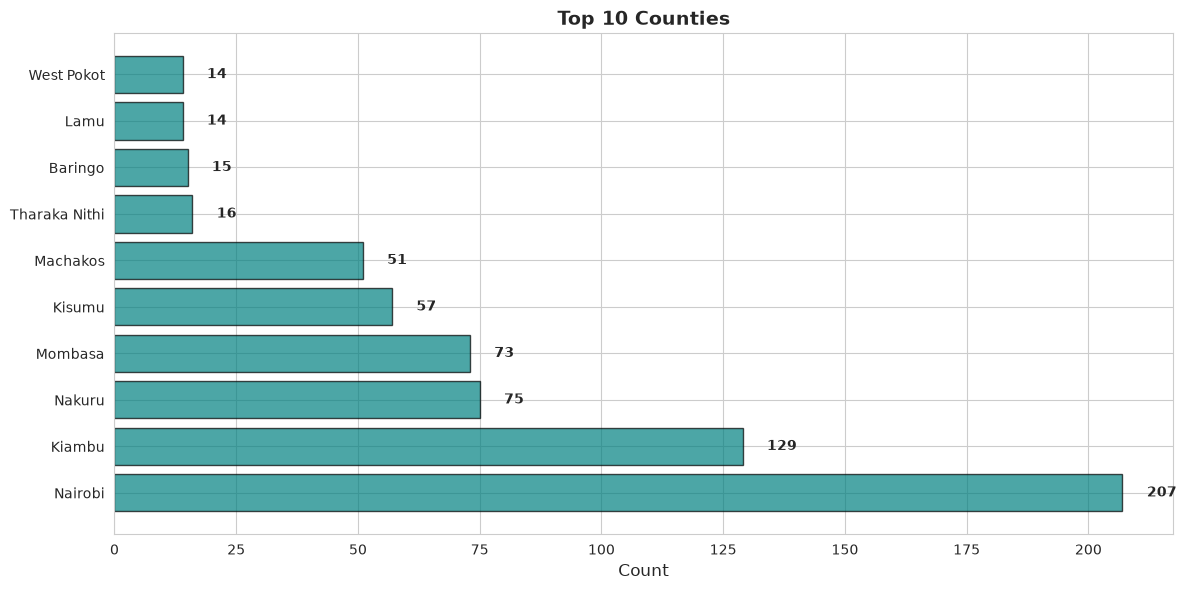

In [12]:
# Top 10 Counties
print('\n=== TOP 10 COUNTIES ===')
top_counties = df_profiles['county'].value_counts().head(10)
print(top_counties)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(top_counties)), top_counties.values, color='teal', alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(top_counties)))
ax.set_yticklabels(top_counties.index)
ax.set_xlabel('Count', fontsize=12)
ax.set_title('Top 10 Counties', fontsize=14, fontweight='bold')
for i, v in enumerate(top_counties.values):
    ax.text(v + 5, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()


=== URBAN vs RURAL CLASSIFICATION ===
urban_rural_classification
rural         40.8
urban         33.7
semi_urban    25.5
Name: proportion, dtype: float64


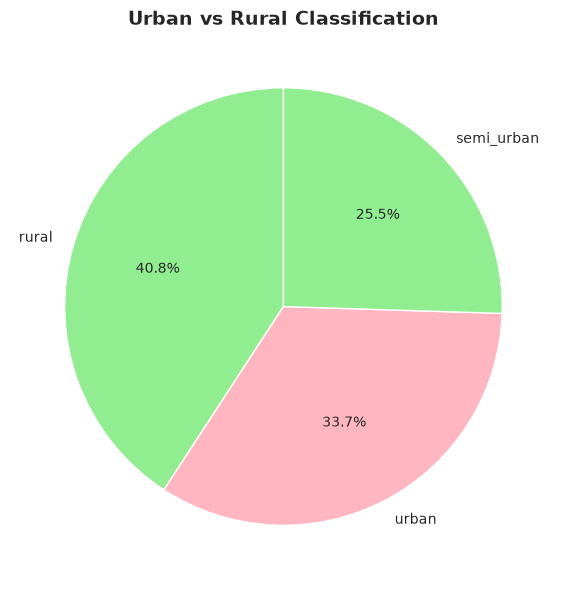

In [13]:
# Urban vs Rural
print('\n=== URBAN vs RURAL CLASSIFICATION ===')
urban_rural = df_profiles['urban_rural_classification'].value_counts()
urban_rural_pct = df_profiles['urban_rural_classification'].value_counts(normalize=True) * 100
print(urban_rural_pct.round(2))

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#90EE90', '#FFB6C1']
wedges, texts, autotexts = ax.pie(urban_rural.values, labels=urban_rural.index,
                                    autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Urban vs Rural Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


=== ARCHETYPE DISTRIBUTION ===
archetype
retail_standard    70.1
micro_merchant     13.4
retail_heavy       13.0
corporate_sme       3.5
Name: proportion, dtype: float64


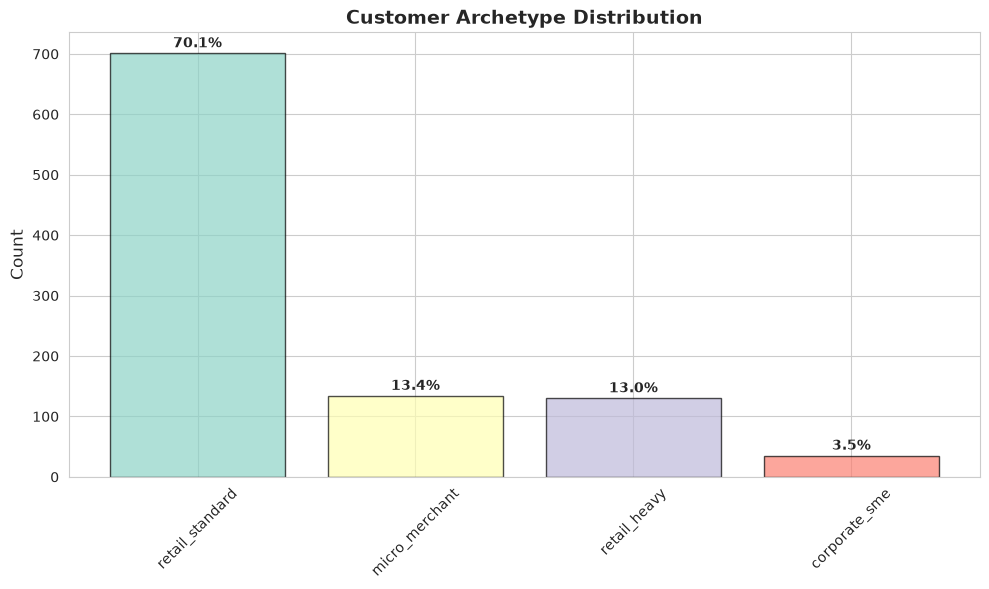

In [14]:
# Archetype Distribution
print('\n=== ARCHETYPE DISTRIBUTION ===')
archetype_counts = df_profiles['archetype'].value_counts()
archetype_pct = df_profiles['archetype'].value_counts(normalize=True) * 100
print(archetype_pct.round(2))

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set3(range(len(archetype_counts)))
ax.bar(archetype_counts.index, archetype_counts.values, color=colors, edgecolor='black', alpha=0.7)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Customer Archetype Distribution', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(archetype_counts.values):
    ax.text(i, v + 10, f'{archetype_pct.iloc[i]:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


=== ACCOUNT AGE STATISTICS ===
Mean: 193.0 days
Median: 187.0 days
Min: 30 days
Max: 365 days


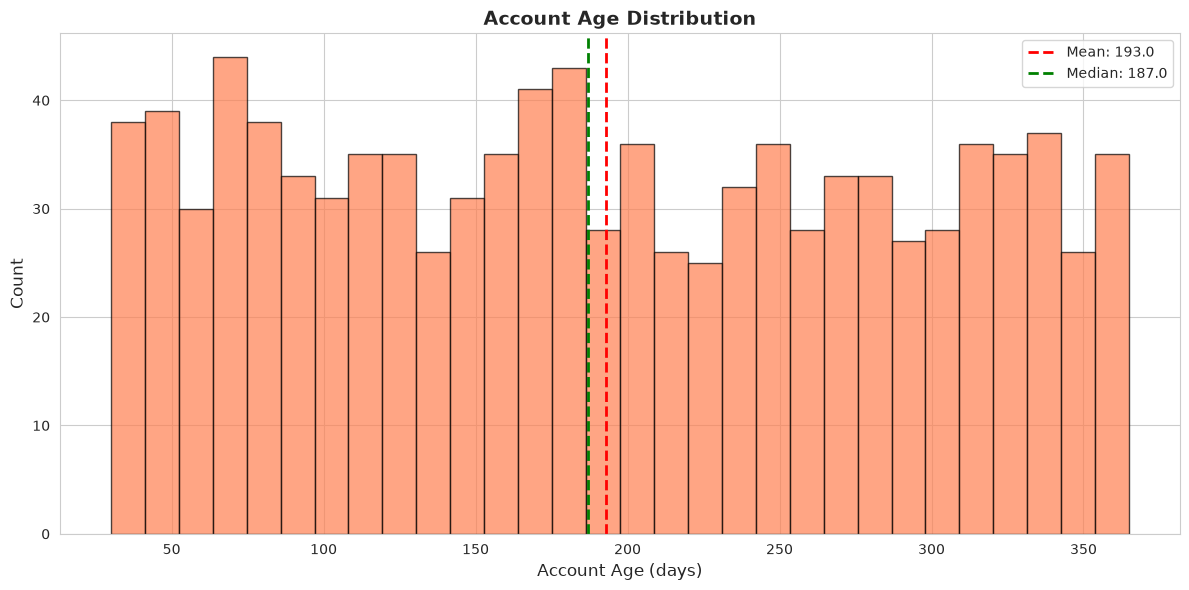

In [15]:
# Account Age
print('\n=== ACCOUNT AGE STATISTICS ===')
print(f'Mean: {df_profiles["account_age_days"].mean():.1f} days')
print(f'Median: {df_profiles["account_age_days"].median():.1f} days')
print(f'Min: {df_profiles["account_age_days"].min()} days')
print(f'Max: {df_profiles["account_age_days"].max()} days')

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df_profiles['account_age_days'], bins=30, alpha=0.7, color='coral', edgecolor='black')
ax.axvline(df_profiles['account_age_days'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_profiles["account_age_days"].mean():.1f}')
ax.axvline(df_profiles['account_age_days'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_profiles["account_age_days"].median():.1f}')
ax.set_xlabel('Account Age (days)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Account Age Distribution', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


=== SPECIAL FLAGS ===
Betting Platform: 2.00% of users
International Transaction: 2.60% of users


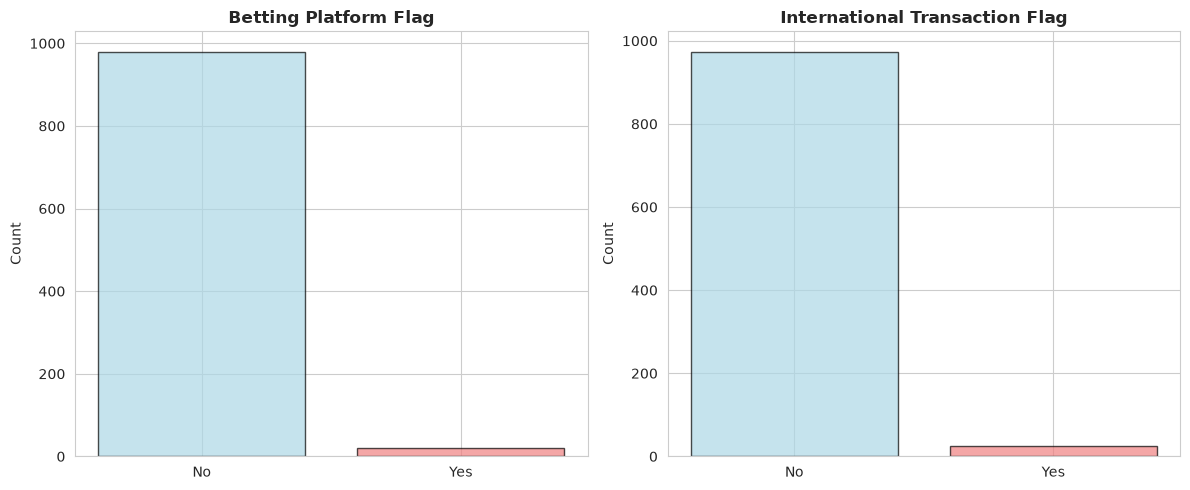

In [16]:
# Betting and International Flags
print('\n=== SPECIAL FLAGS ===')
betting_pct = df_profiles['betting_platform_flag'].sum() / len(df_profiles) * 100
international_pct = df_profiles['international_transaction_flag'].sum() / len(df_profiles) * 100

print(f'Betting Platform: {betting_pct:.2f}% of users')
print(f'International Transaction: {international_pct:.2f}% of users')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
betting_counts = df_profiles['betting_platform_flag'].value_counts()
international_counts = df_profiles['international_transaction_flag'].value_counts()

axes[0].bar(['No', 'Yes'], [betting_counts[0], betting_counts[1]], color=['lightblue', 'lightcoral'], edgecolor='black', alpha=0.7)
axes[0].set_title('Betting Platform Flag', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].bar(['No', 'Yes'], [international_counts[0], international_counts[1]], color=['lightblue', 'lightcoral'], edgecolor='black', alpha=0.7)
axes[1].set_title('International Transaction Flag', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [20]:
# Check the tier limits. Ensure there is no mistake
# Tier Limit Validation
print('\n=== TIER LIMIT VALIDATION ===')
tier_limits = {
    'tier_1': (500000, 1000000),
    'tier_2': (250000, 500000),
    'tier_3': (100000, 200000)
}

for tier, (tx_limit, bal_limit) in tier_limits.items():
    tier_data = df_profiles[df_profiles['kyc_tier'] == tier]
    max_tx = tier_data['max_transaction_limit_kes'].max()
    max_bal = tier_data['max_balance_limit_kes'].max()
    tx_status = '✅' if max_tx <= tx_limit else '⚠️'
    bal_status = '✅' if max_bal <= bal_limit else '⚠️'
    print(f'{tx_status} {tier} TX limit: max observed {max_tx} ≤ {tx_limit}')
    print(f'{bal_status} {tier} BAL limit: max observed {max_bal} ≤ {bal_limit}')


=== TIER LIMIT VALIDATION ===
✅ tier_1 TX limit: max observed 70000.0 ≤ 500000
✅ tier_1 BAL limit: max observed 300000.0 ≤ 1000000
✅ tier_2 TX limit: max observed 150000.0 ≤ 250000
✅ tier_2 BAL limit: max observed 500000.0 ≤ 500000
⚠️ tier_3 TX limit: max observed 250000.0 ≤ 100000
⚠️ tier_3 BAL limit: max observed 500000.0 ≤ 200000


## Section 3: Transaction Value Validation

Analyze transaction amounts, types, and risk indicators.


=== TRANSACTION AMOUNT STATISTICS ===
Mean: 2346.75 KES
Median: 853.28 KES
Std Dev: 5620.10 KES
Min: 4.25 KES
Max: 144670.19 KES


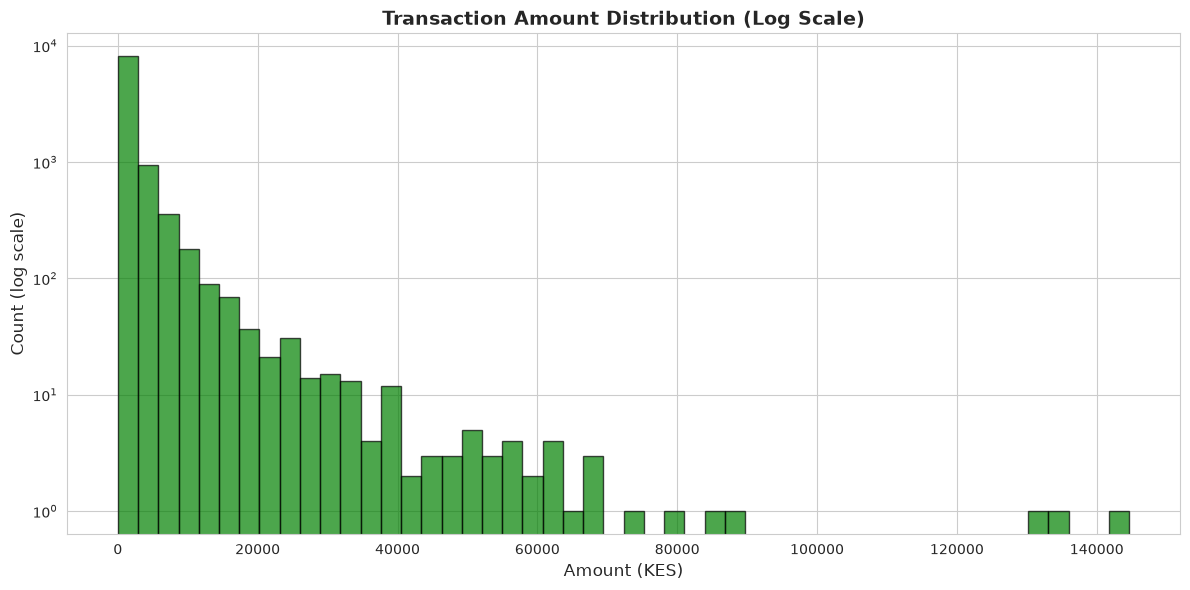

In [21]:
# Amount Distribution
print('\n=== TRANSACTION AMOUNT STATISTICS ===')
print(f'Mean: {df_transactions["amount"].mean():.2f} KES')
print(f'Median: {df_transactions["amount"].median():.2f} KES')
print(f'Std Dev: {df_transactions["amount"].std():.2f} KES')
print(f'Min: {df_transactions["amount"].min():.2f} KES')
print(f'Max: {df_transactions["amount"].max():.2f} KES')

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df_transactions['amount'], bins=50, alpha=0.7, color='green', edgecolor='black')
ax.set_xlabel('Amount (KES)', fontsize=12)
ax.set_ylabel('Count (log scale)', fontsize=12)
ax.set_yscale('log')
ax.set_title('Transaction Amount Distribution (Log Scale)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


=== AMOUNT BY TRANSACTION TYPE ===
                            count     mean  median      std    min        max
transaction_type                                                             
Agent Deposit                1002  2283.59  904.02  4732.24  11.56   61034.43
Agent Withdrawal              971  2647.88  862.88  7444.57  14.38  144670.19
Lipa Na M-PESA (Buy Goods)   1194  2570.18  870.44  6364.57   4.25  131565.83
Lipa Na M-PESA (Paybill)     1472  2333.31  912.87  5089.74  20.35   79174.36
Others                        792  2244.45  841.06  4690.99  18.97   69025.45
Received Money               2123  2355.60  829.82  5468.69  11.47   84557.16
Send Money                   2446  2177.56  811.04  5431.00   8.35  134034.97


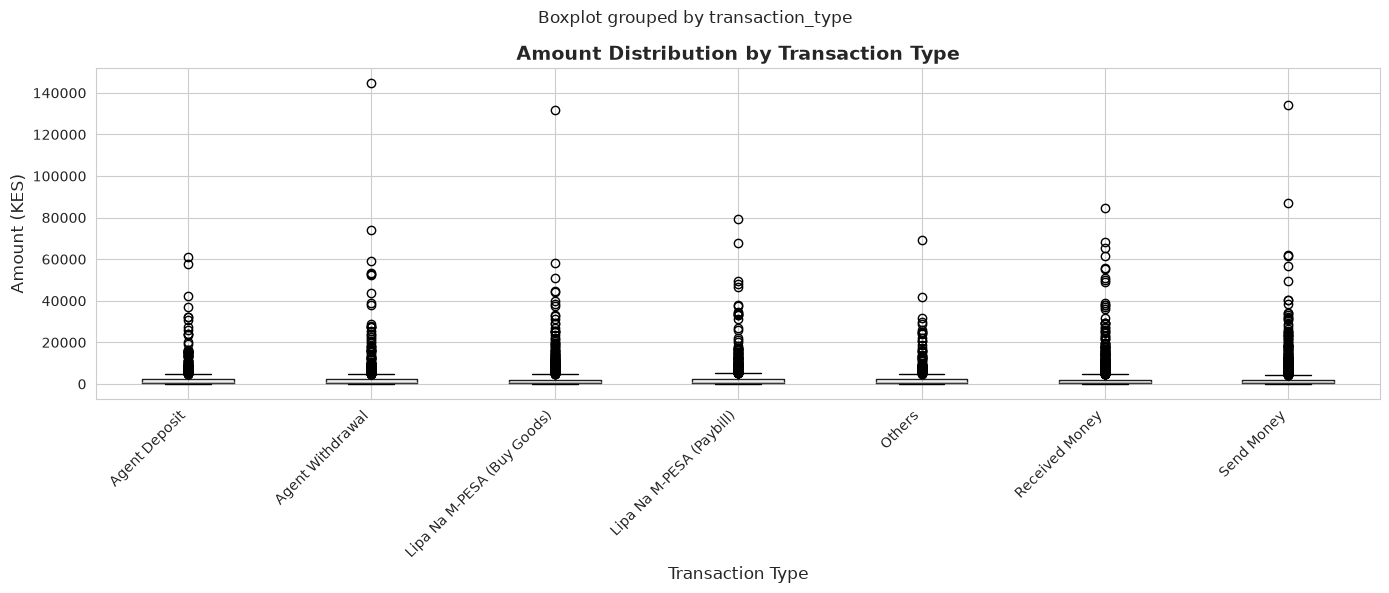

In [22]:
# Amount by Transaction Type
print('\n=== AMOUNT BY TRANSACTION TYPE ===')
tx_type_stats = df_transactions.groupby('transaction_type')['amount'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
print(tx_type_stats.round(2))

fig, ax = plt.subplots(figsize=(14, 6))
df_transactions.boxplot(column='amount', by='transaction_type', ax=ax)
ax.set_xlabel('Transaction Type', fontsize=12)
ax.set_ylabel('Amount (KES)', fontsize=12)
ax.set_title('Amount Distribution by Transaction Type', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [23]:
# Kadogo Classification
print('\n=== KADOGO (SMALL) TRANSACTIONS ===')
kadogo_count = df_transactions['is_kadogo'].sum()
kadogo_pct = kadogo_count / len(df_transactions) * 100
print(f'Kadogo transactions: {kadogo_count} ({kadogo_pct:.2f}%)')

# Kadogo by archetype
merged = df_transactions.merge(df_profiles[['customer_id', 'archetype']], on='customer_id', how='left')
kadogo_by_archetype = merged.groupby('archetype')['is_kadogo'].apply(lambda x: (x.sum() / len(x) * 100))
print('\nKadogo % by Archetype:')
print(kadogo_by_archetype.round(2))


=== KADOGO (SMALL) TRANSACTIONS ===
Kadogo transactions: 581 (5.81%)

Kadogo % by Archetype:
archetype
corporate_sme      5.06
micro_merchant     1.47
retail_heavy       3.95
retail_standard    7.05
Name: is_kadogo, dtype: float64


In [24]:
# Max Transaction per Tier
print('\n=== MAX TRANSACTION AMOUNT PER TIER ===')
tx_by_tier = df_transactions.merge(df_profiles[['customer_id', 'kyc_tier']], on='customer_id', how='left')
max_tx_per_tier = tx_by_tier.groupby('kyc_tier')['amount'].max()
print(max_tx_per_tier.round(2))

tier_limits_tx = {'tier_1': 500000, 'tier_2': 250000, 'tier_3': 100000}
print('\nValidation vs Tier Limits:')
for tier in ['tier_1', 'tier_2', 'tier_3']:
    observed = max_tx_per_tier[tier]
    limit = tier_limits_tx[tier]
    status = '✅' if observed <= limit else '⚠️'
    print(f'{status} {tier}: max {observed:.0f} ≤ limit {limit}')


=== MAX TRANSACTION AMOUNT PER TIER ===
kyc_tier
tier_1     69025.45
tier_2    144670.19
tier_3     58993.68
Name: amount, dtype: float64

Validation vs Tier Limits:
✅ tier_1: max 69025 ≤ limit 500000
✅ tier_2: max 144670 ≤ limit 250000
✅ tier_3: max 58994 ≤ limit 100000


In [25]:
# Max Balance per Tier
print('\n=== MAX BALANCE PER TIER ===')
max_bal_per_tier = tx_by_tier.groupby('kyc_tier')['balance_after'].max()
print(max_bal_per_tier.round(2))

tier_limits_bal = {'tier_1': 1000000, 'tier_2': 500000, 'tier_3': 200000}
print('\nValidation vs Tier Limits:')
for tier in ['tier_1', 'tier_2', 'tier_3']:
    observed = max_bal_per_tier[tier]
    limit = tier_limits_bal[tier]
    status = '✅' if observed <= limit else '⚠️'
    print(f'{status} {tier}: max {observed:.0f} ≤ limit {limit}')


=== MAX BALANCE PER TIER ===
kyc_tier
tier_1    291485.38
tier_2    495110.97
tier_3    480610.80
Name: balance_after, dtype: float64

Validation vs Tier Limits:
✅ tier_1: max 291485 ≤ limit 1000000
✅ tier_2: max 495111 ≤ limit 500000
⚠️ tier_3: max 480611 ≤ limit 200000


In [26]:
# Negative Balance Check (Critical)
print('\n=== NEGATIVE BALANCE CHECK ===')
neg_balance_count = (df_transactions['balance_after'] < 0).sum()
status = '✅' if neg_balance_count == 0 else '⚠️'
print(f'{status} Negative balances: {neg_balance_count} (should be 0)')
print(f'{status} Min balance: {df_transactions["balance_after"].min():.2f} KES')


=== NEGATIVE BALANCE CHECK ===
✅ Negative balances: 0 (should be 0)
✅ Min balance: 0.41 KES


In [27]:
# Duplicate Records Check
print('\n=== DUPLICATE RECORDS CHECK ===')
dup_count = df_transactions.duplicated().sum()
status = '✅' if dup_count == 0 else '⚠️'
print(f'{status} Duplicate transaction rows: {dup_count}')

dup_tx_id = df_transactions['transaction_id'].duplicated().sum()
status = '✅' if dup_tx_id == 0 else '⚠️'
print(f'{status} Duplicate transaction_id: {dup_tx_id}')


=== DUPLICATE RECORDS CHECK ===
✅ Duplicate transaction rows: 0
✅ Duplicate transaction_id: 0


## Section 4: Temporal Patterns

Analyze transaction timing, daily cycles, and patterns.


=== HOURLY DISTRIBUTION ===
hour
0       9
1      15
2      12
3      15
4      16
5      18
6     272
7     246
8     278
9     658
10    666
11    706
12    682
13    588
14    668
15    616
16    744
17    753
18    715
19    737
20    412
21    420
22    354
23    400
Name: count, dtype: int64


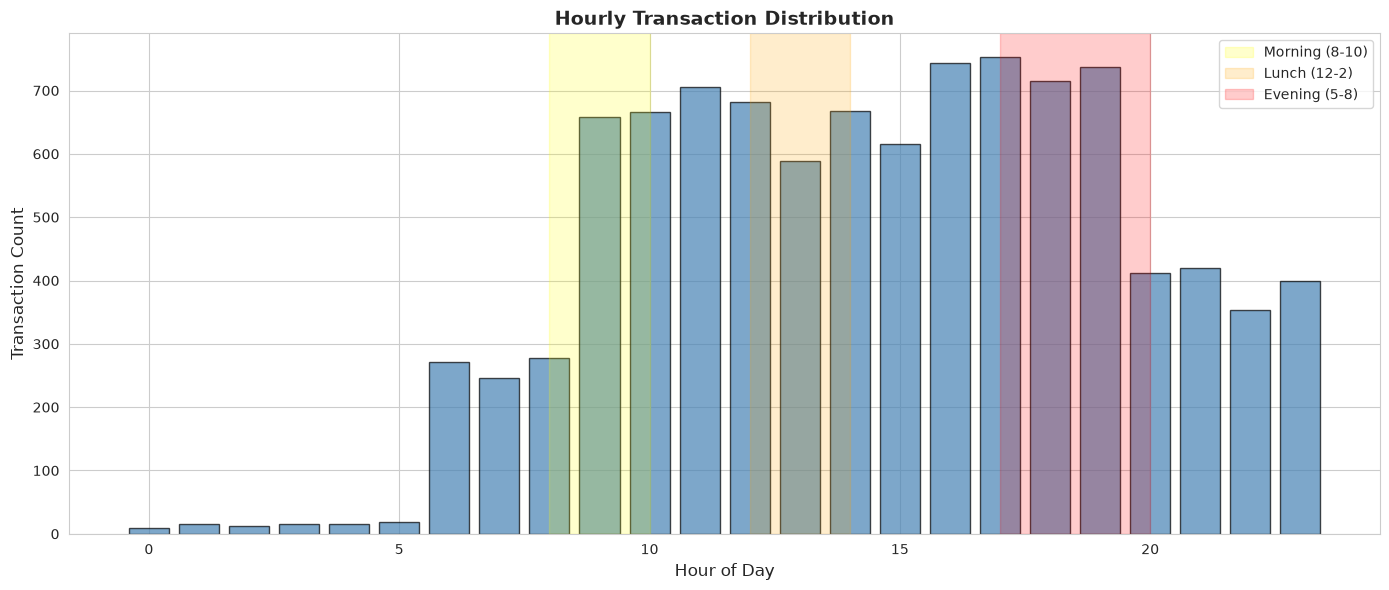

In [30]:
# Hourly Distribution
print('\n=== HOURLY DISTRIBUTION ===')
hourly_counts = df_transactions['hour'].value_counts().sort_index()
print(hourly_counts)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(hourly_counts.index, hourly_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvspan(8, 10, alpha=0.2, color='yellow', label='Morning (8-10)')
ax.axvspan(12, 14, alpha=0.2, color='orange', label='Lunch (12-2)')
ax.axvspan(17, 20, alpha=0.2, color='red', label='Evening (5-8)')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Transaction Count', fontsize=12)
ax.set_title('Hourly Transaction Distribution', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


=== HOUR × DAY OF WEEK HEATMAP ===


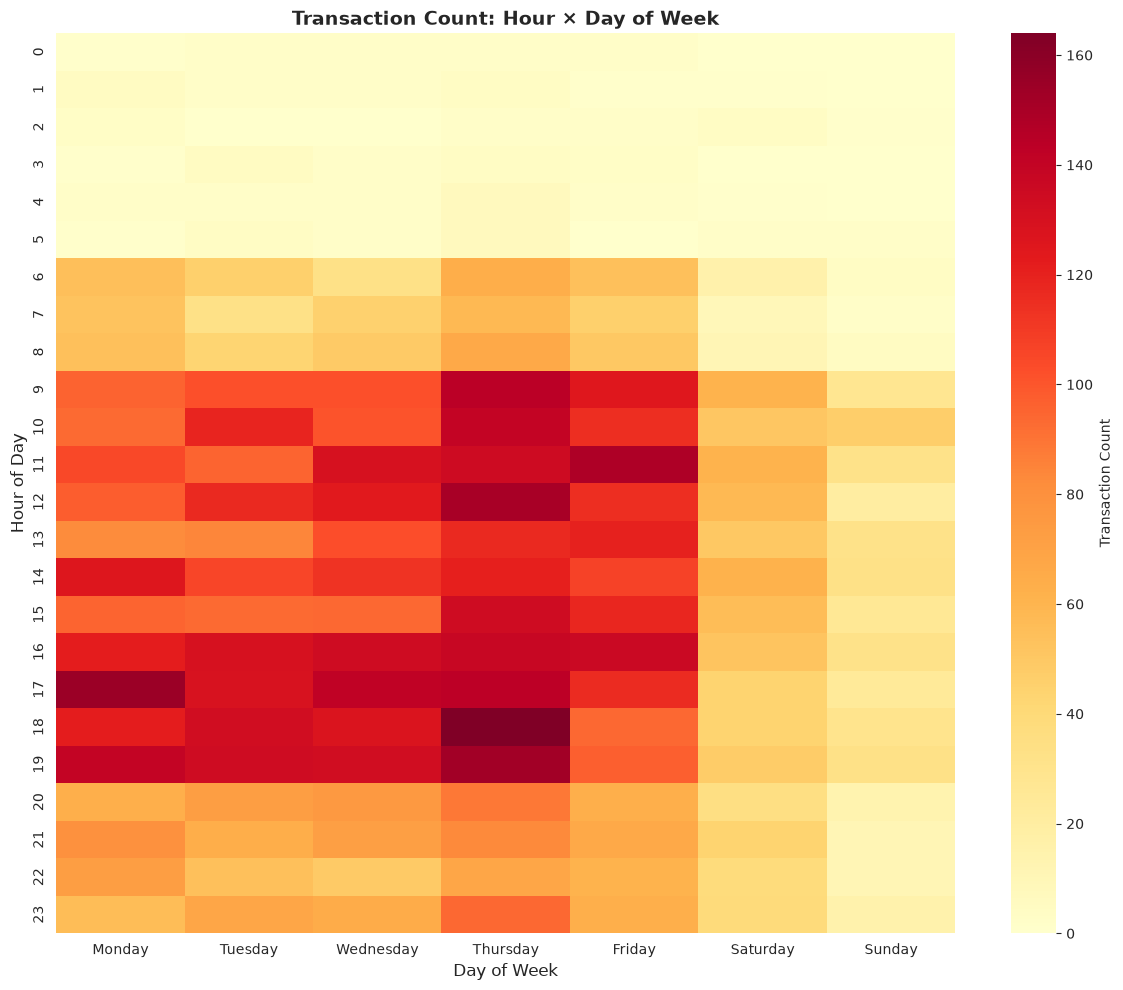

In [31]:
# Hour × Day of Week Heatmap
print('\n=== HOUR × DAY OF WEEK HEATMAP ===')
heatmap_data = pd.crosstab(df_transactions['hour'], df_transactions['day_of_week'])

# Map day integers to names
day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
heatmap_data.columns = [day_map.get(col, str(col)) for col in heatmap_data.columns]
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data[[d for d in day_order if d in heatmap_data.columns]]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(heatmap_data, cmap='YlOrRd', cbar_kws={'label': 'Transaction Count'}, ax=ax)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Hour of Day', fontsize=12)
ax.set_title('Transaction Count: Hour × Day of Week', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


=== WEEKLY PATTERN ===
day_of_week
Monday       1681
Tuesday      1638
Wednesday    1702
Thursday     2086
Friday       1704
Saturday      787
Sunday        402
Name: count, dtype: int64


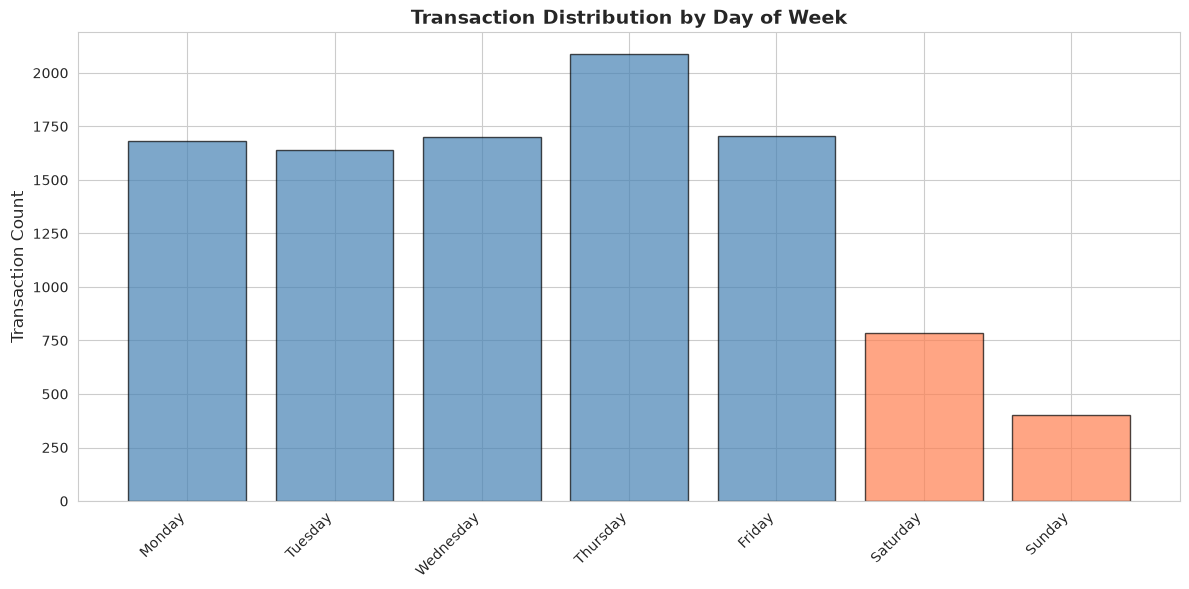

In [32]:
# Weekly Pattern
print('\n=== WEEKLY PATTERN ===')
# Map day integers to names
day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
weekly_counts = df_transactions['day_of_week'].map(day_map).value_counts()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_counts = weekly_counts.reindex(day_order)
print(weekly_counts)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['steelblue'] * 5 + ['coral'] * 2  # weekday vs weekend
ax.bar(range(len(weekly_counts)), weekly_counts.values, color=colors, edgecolor='black', alpha=0.7)
ax.set_xticks(range(len(weekly_counts)))
ax.set_xticklabels(weekly_counts.index, rotation=45, ha='right')
ax.set_ylabel('Transaction Count', fontsize=12)
ax.set_title('Transaction Distribution by Day of Week', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


=== MONTHLY PATTERN ===
month
7    10000
Name: count, dtype: int64


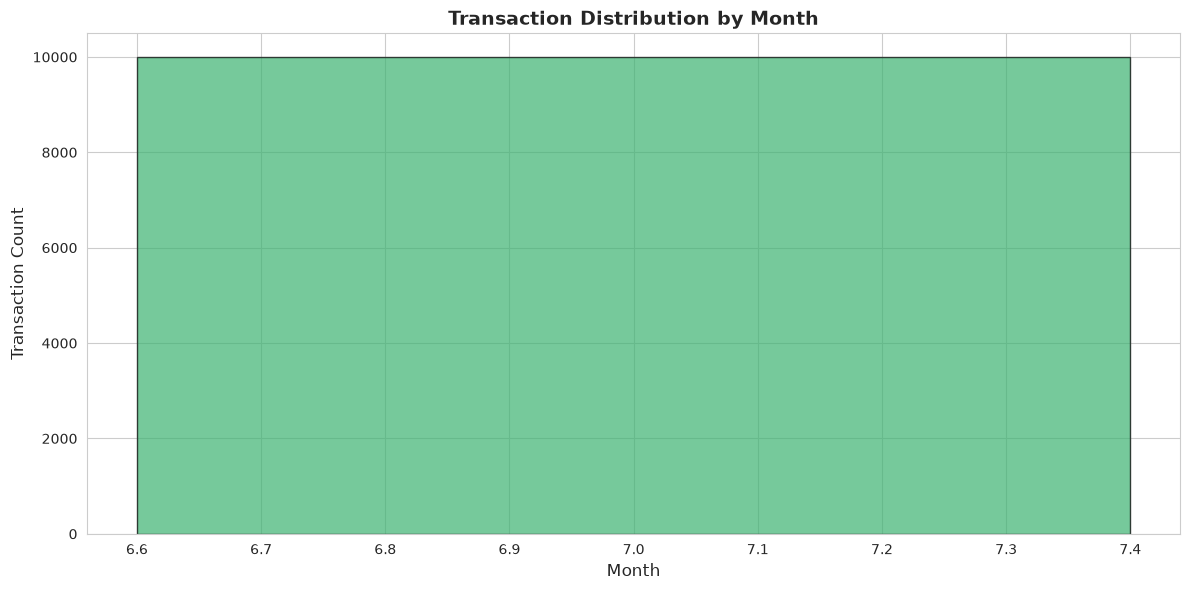

In [33]:
# Monthly Pattern
print('\n=== MONTHLY PATTERN ===')
monthly_counts = df_transactions['month'].value_counts().sort_index()
print(monthly_counts)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(monthly_counts.index, monthly_counts.values, color='mediumseagreen', edgecolor='black', alpha=0.7)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Transaction Count', fontsize=12)
ax.set_title('Transaction Distribution by Month', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
# Weekend Analysis
print('\n=== WEEKEND ANALYSIS ===')
weekend_counts = df_transactions['is_weekend'].value_counts()
print(f'Weekday: {weekend_counts[0]}')
print(f'Weekend: {weekend_counts[1]}')
weekend_pct = weekend_counts[1] / len(df_transactions) * 100
print(f'Weekend %: {weekend_pct:.2f}%')

# Compare weekend vs weekday amounts
print('\nAmount Statistics:')
weekday_amounts = df_transactions[df_transactions['is_weekend'] == 0]['amount']
weekend_amounts = df_transactions[df_transactions['is_weekend'] == 1]['amount']
print(f'Weekday mean amount: {weekday_amounts.mean():.2f} KES')
print(f'Weekend mean amount: {weekend_amounts.mean():.2f} KES')


=== WEEKEND ANALYSIS ===
Weekday: 8811
Weekend: 1189
Weekend %: 11.89%

Amount Statistics:
Weekday mean amount: 2326.26 KES
Weekend mean amount: 2498.65 KES


In [35]:
# Night vs Day Pattern
print('\n=== NIGHT vs DAY PATTERN ===')
night_counts = df_transactions['is_night'].value_counts()
print(f'Day: {night_counts[0]}')
print(f'Night: {night_counts[1]}')
night_pct = night_counts[1] / len(df_transactions) * 100
print(f'Night %: {night_pct:.2f}%')


=== NIGHT vs DAY PATTERN ===
Day: 9161
Night: 839
Night %: 8.39%



=== USERS WITH CONSISTENT HOURLY PATTERNS ===
Users with >70% txns in same hour: 1 (0.10%)


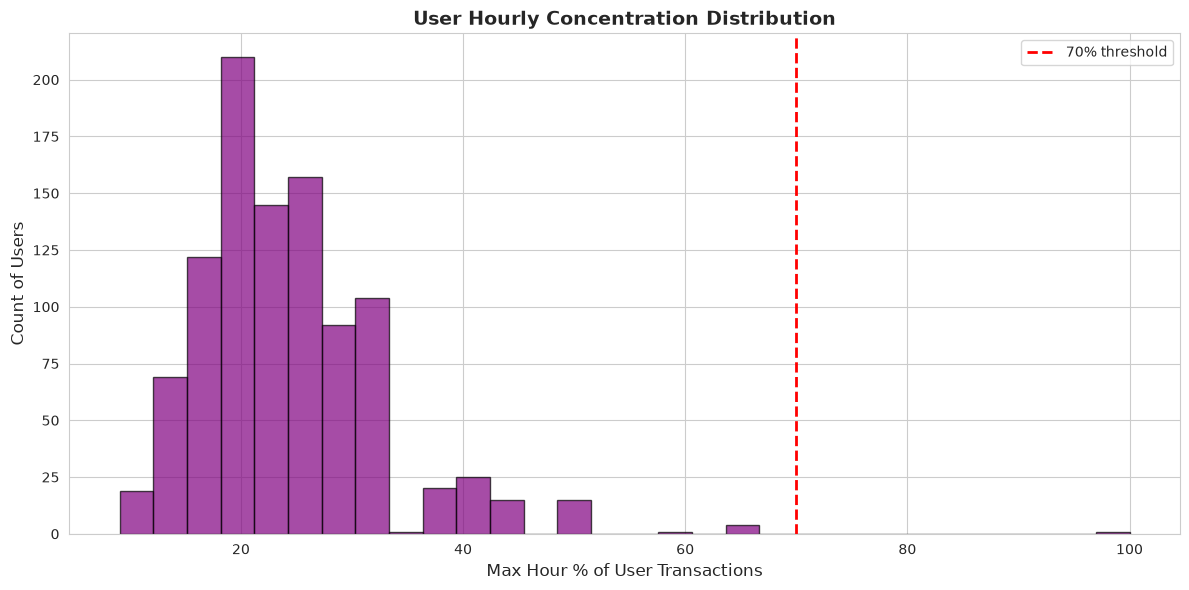

In [36]:
# User Daily Pattern Detection
print('\n=== USERS WITH CONSISTENT HOURLY PATTERNS ===')
user_hourly = df_transactions.groupby('customer_id').apply(
    lambda x: x['hour'].value_counts().iloc[0] / len(x) * 100
)
consistent_users = (user_hourly > 70).sum()
pct_consistent = consistent_users / len(user_hourly) * 100
print(f'Users with >70% txns in same hour: {consistent_users} ({pct_consistent:.2f}%)')

# Distribution of max hourly concentration
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(user_hourly, bins=30, alpha=0.7, color='purple', edgecolor='black')
ax.axvline(70, color='red', linestyle='--', linewidth=2, label='70% threshold')
ax.set_xlabel('Max Hour % of User Transactions', fontsize=12)
ax.set_ylabel('Count of Users', fontsize=12)
ax.set_title('User Hourly Concentration Distribution', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
# Merge temporal features and validate
print('\n=== TEMPORAL FEATURES VALIDATION ===')
print('Sample temporal features:')
print(df_temporal[['user_id', 'dominant_hour', 'dominant_hour_pct', 'has_consistent_pattern', 'hourly_entropy']].head(10))

print('\nConsistent pattern stats:')
print(df_temporal['has_consistent_pattern'].value_counts())
print(f'Pct with consistent pattern: {df_temporal["has_consistent_pattern"].sum() / len(df_temporal) * 100:.2f}%')


=== TEMPORAL FEATURES VALIDATION ===
Sample temporal features:
       user_id  dominant_hour  dominant_hour_pct  has_consistent_pattern  \
0  CUST_000239             15            28.5714                   False   
1  CUST_000143              9            25.0000                   False   
2  CUST_000477             21            22.2222                   False   
3  CUST_000339             12            16.6667                   False   
4  CUST_000165             18            22.2222                   False   
5  CUST_000117              9            20.0000                   False   
6  CUST_000850             20            11.1111                   False   
7  CUST_000547             19            25.0000                   False   
8  CUST_000978             17            25.0000                   False   
9  CUST_000653             15            18.1818                   False   

   hourly_entropy  
0          2.2359  
1          3.0221  
2          2.7255  
3          3.0441  

## Section 5: Geographic Patterns

Analyze customer and transaction locations.


=== TOP 15 COUNTIES BY TRANSACTION VOLUME ===
county
Nairobi          2056
Kiambu           1265
Nakuru            774
Mombasa           725
Kisumu            547
Machakos          485
Tharaka Nithi     167
Lamu              152
Baringo           151
Kwale             143
Nyandarua         141
Laikipia          140
Meru              128
Migori            126
West Pokot        122
Name: count, dtype: int64


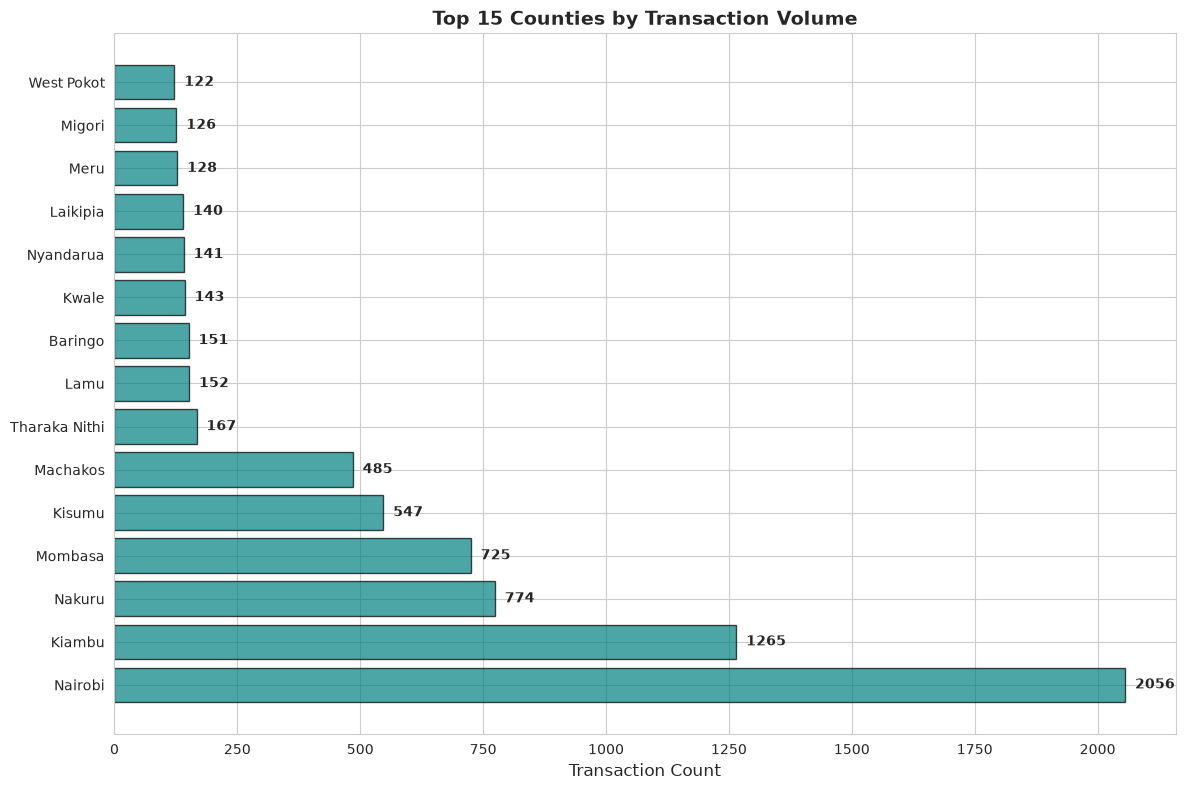

In [38]:
# Top 15 Counties
print('\n=== TOP 15 COUNTIES BY TRANSACTION VOLUME ===')
merged_geo = df_transactions.merge(df_profiles[['customer_id', 'county']], on='customer_id', how='left')
county_tx_counts = merged_geo['county'].value_counts().head(15)
print(county_tx_counts)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(county_tx_counts)), county_tx_counts.values, color='teal', edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(county_tx_counts)))
ax.set_yticklabels(county_tx_counts.index)
ax.set_xlabel('Transaction Count', fontsize=12)
ax.set_title('Top 15 Counties by Transaction Volume', fontsize=14, fontweight='bold')
for i, v in enumerate(county_tx_counts.values):
    ax.text(v + 20, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.show()


=== URBAN vs RURAL TRANSACTION VOLUME ===
urban_rural_classification
rural         4148
urban         3328
semi_urban    2524
Name: count, dtype: int64

Percentages:
urban_rural_classification
rural         41.48
urban         33.28
semi_urban    25.24
Name: proportion, dtype: float64


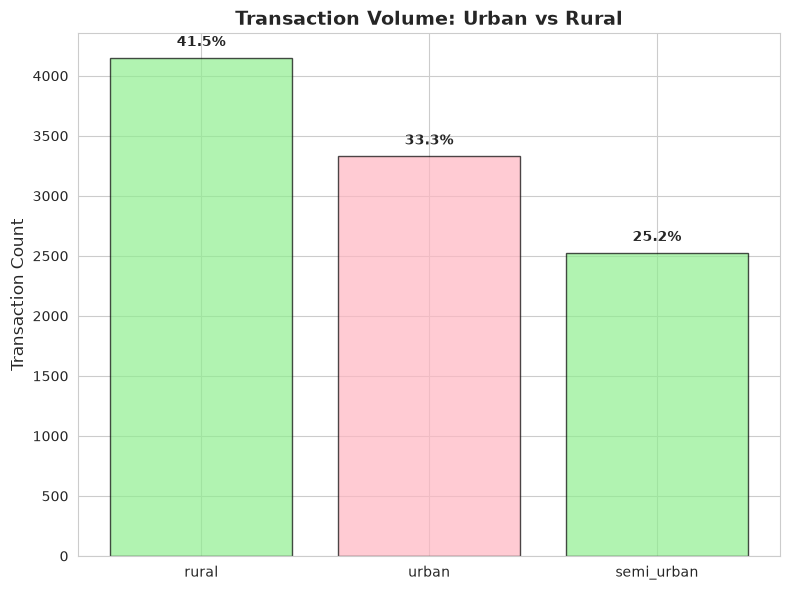

In [39]:
# Urban vs Rural Transaction Volume
print('\n=== URBAN vs RURAL TRANSACTION VOLUME ===')
merged_urb = df_transactions.merge(df_profiles[['customer_id', 'urban_rural_classification']], on='customer_id', how='left')
urban_rural_tx = merged_urb['urban_rural_classification'].value_counts()
urban_rural_tx_pct = merged_urb['urban_rural_classification'].value_counts(normalize=True) * 100
print(urban_rural_tx)
print(f'\nPercentages:\n{urban_rural_tx_pct.round(2)}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(urban_rural_tx.index, urban_rural_tx.values, color=['#90EE90', '#FFB6C1'], edgecolor='black', alpha=0.7)
ax.set_ylabel('Transaction Count', fontsize=12)
ax.set_title('Transaction Volume: Urban vs Rural', fontsize=14, fontweight='bold')
for i, v in enumerate(urban_rural_tx.values):
    ax.text(i, v + 100, f'{urban_rural_tx_pct.iloc[i]:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Section 6: Network & Relationships

Analyze customer interactions and network patterns.


=== COUNTERPARTY ANALYSIS ===
Mean counterparties per user: 9.94
Median counterparties per user: 10.00
Min: 1
Max: 20


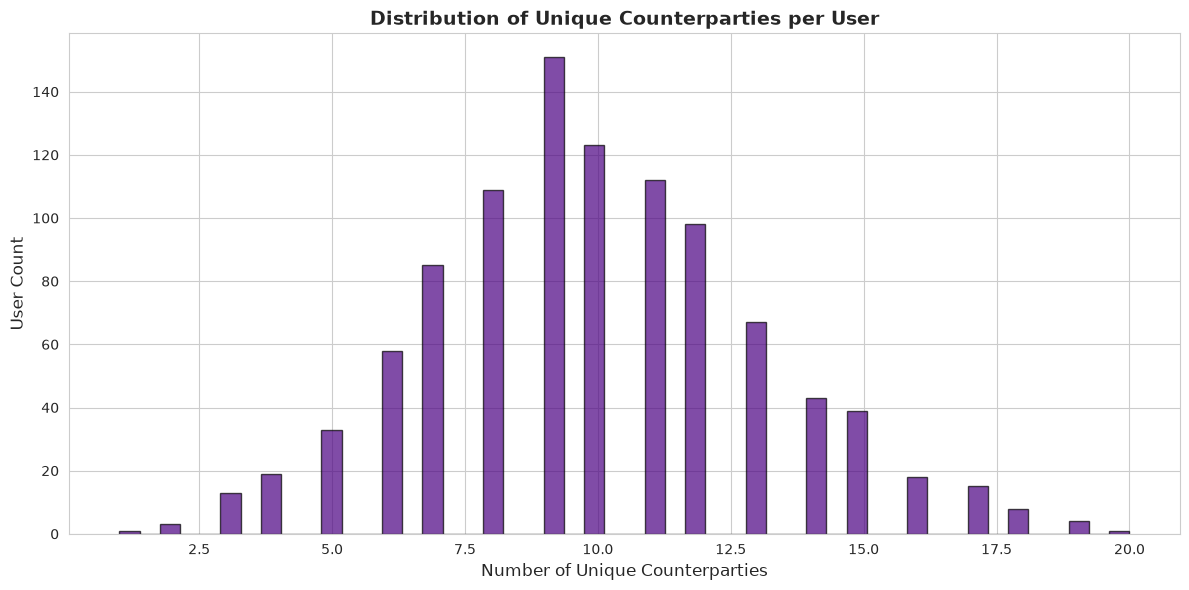

In [40]:
# Unique Counterparties per User
print('\n=== COUNTERPARTY ANALYSIS ===')
counterparties_per_user = df_transactions.groupby('customer_id')['counterparty'].nunique()
print(f'Mean counterparties per user: {counterparties_per_user.mean():.2f}')
print(f'Median counterparties per user: {counterparties_per_user.median():.2f}')
print(f'Min: {counterparties_per_user.min()}')
print(f'Max: {counterparties_per_user.max()}')

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(counterparties_per_user, bins=50, alpha=0.7, color='indigo', edgecolor='black')
ax.set_xlabel('Number of Unique Counterparties', fontsize=12)
ax.set_ylabel('User Count', fontsize=12)
ax.set_title('Distribution of Unique Counterparties per User', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
# Betting Users
print('\n=== BETTING BEHAVIOR ===')
betting_users = df_profiles['betting_platform_flag'].sum()
betting_user_ids = df_profiles[df_profiles['betting_platform_flag'] == 1]['customer_id'].values
betting_tx_count = df_transactions[df_transactions['customer_id'].isin(betting_user_ids)].shape[0]

print(f'Total betting-flagged users: {betting_users}')
print(f'Pct of all users: {betting_users / len(df_profiles) * 100:.2f}%')
print(f'Transactions from betting users: {betting_tx_count}')
print(f'Pct of all transactions: {betting_tx_count / len(df_transactions) * 100:.2f}%')


=== BETTING BEHAVIOR ===
Total betting-flagged users: 20
Pct of all users: 2.00%
Transactions from betting users: 189
Pct of all transactions: 1.89%


In [42]:
# International Users
print('\n=== INTERNATIONAL TRANSACTION USERS ===')
intl_users = df_profiles['international_transaction_flag'].sum()
intl_user_ids = df_profiles[df_profiles['international_transaction_flag'] == 1]['customer_id'].values
intl_tx_count = df_transactions[df_transactions['customer_id'].isin(intl_user_ids)].shape[0]

print(f'Total intl-flagged users: {intl_users}')
print(f'Pct of all users: {intl_users / len(df_profiles) * 100:.2f}%')
print(f'Transactions from intl users: {intl_tx_count}')
print(f'Pct of all transactions: {intl_tx_count / len(df_transactions) * 100:.2f}%')


=== INTERNATIONAL TRANSACTION USERS ===
Total intl-flagged users: 26
Pct of all users: 2.60%
Transactions from intl users: 274
Pct of all transactions: 2.74%



=== NETWORK VISUALIZATION ===


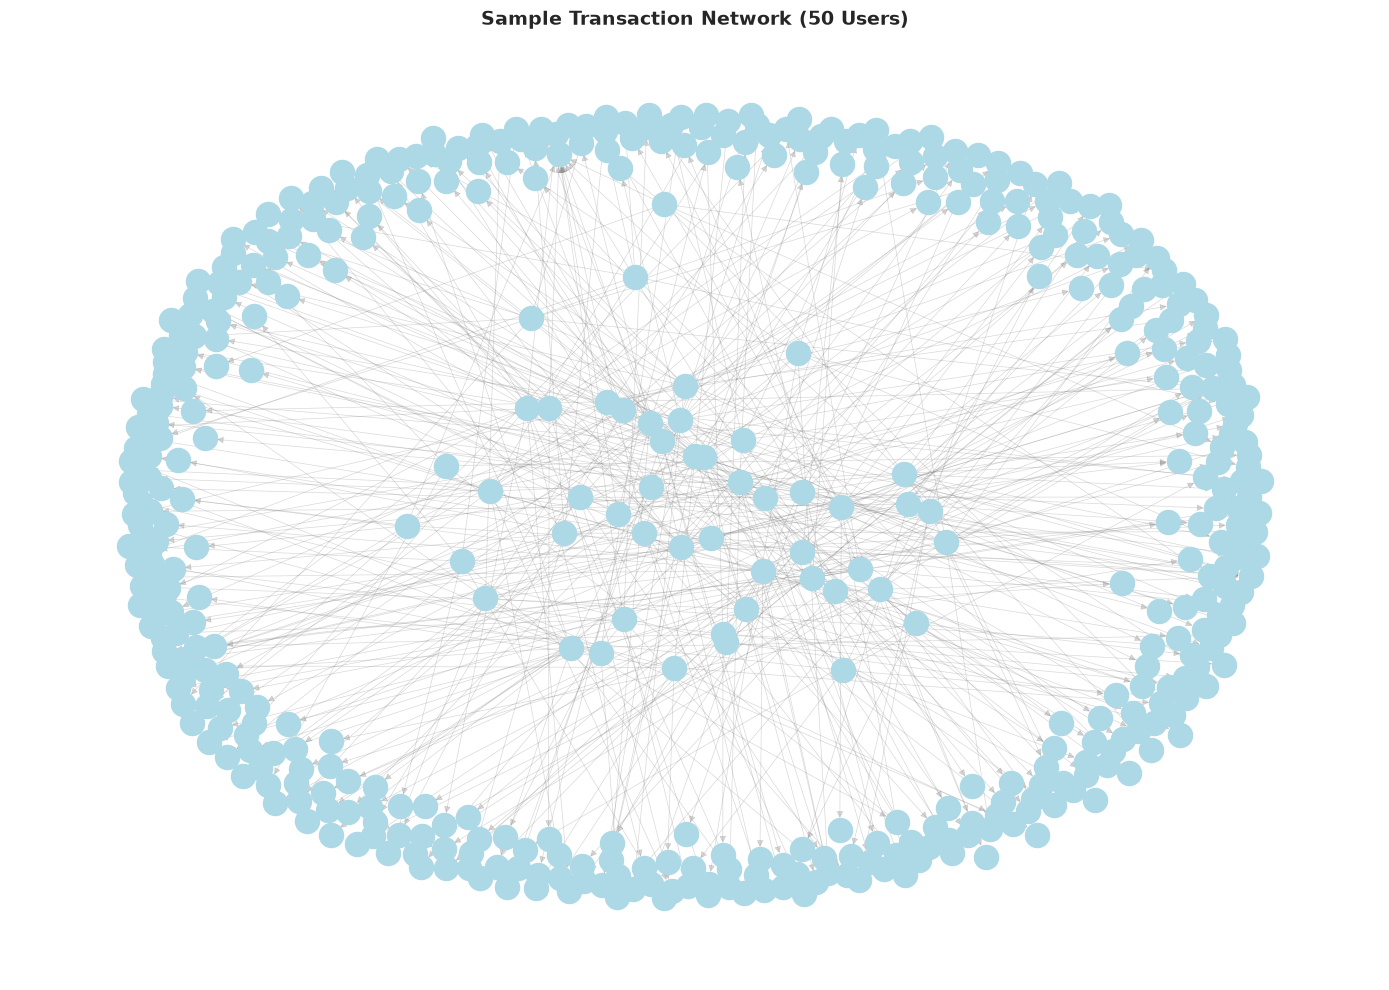

Network nodes: 487
Network edges: 481


In [43]:
# Simple Network Graph
print('\n=== NETWORK VISUALIZATION ===')
# Sample 50 users
sample_users = df_profiles.sample(min(50, len(df_profiles)), random_state=42)['customer_id'].values
sample_tx = df_transactions[df_transactions['customer_id'].isin(sample_users)]

# Create directed graph
G = nx.DiGraph()
for _, row in sample_tx.iterrows():
    G.add_edge(row['customer_id'], row['counterparty'], weight=row['amount'])

# Draw
fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=300, ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.5, edge_color='gray', ax=ax)
ax.set_title('Sample Transaction Network (50 Users)', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Network nodes: {G.number_of_nodes()}')
print(f'Network edges: {G.number_of_edges()}')

## Section 7: AML Detectability

Analyze launderer characteristics and feature separation.

In [44]:
# Ground Truth Distribution
print('\n=== GROUND TRUTH DISTRIBUTION ===')
print(df_truth['is_launderer'].value_counts())
launderer_pct = df_truth['is_launderer'].sum() / len(df_truth) * 100
status = '✅' if abs(launderer_pct - 2) < 0.5 else '⚠️'
print(f'{status} Launderer %: {launderer_pct:.2f}% (expected ~2%)')

print('\nAML Scenarios:')
scenario_counts = df_truth[df_truth['is_launderer'] == 1]['aml_scenario'].value_counts()
print(scenario_counts)
scenario_pct = scenario_counts / scenario_counts.sum() * 100
print('\nExpected: smurfing ~40%, layering ~30%, mule ~20%, circular ~10%')
print(scenario_pct.round(2))


=== GROUND TRUTH DISTRIBUTION ===
is_launderer
False    980
True      20
Name: count, dtype: int64
✅ Launderer %: 2.00% (expected ~2%)

AML Scenarios:
aml_scenario
smurfing            8
layering            6
mule_account        4
circular_trading    2
Name: count, dtype: int64

Expected: smurfing ~40%, layering ~30%, mule ~20%, circular ~10%
aml_scenario
smurfing            40.0
layering            30.0
mule_account        20.0
circular_trading    10.0
Name: count, dtype: float64


In [45]:
# Aggregate Transaction Features by User
print('\n=== AGGREGATING TRANSACTION METRICS BY USER ===')

agg_metrics = df_transactions.groupby('customer_id').agg({
    'transaction_id': 'count',  # tx_count
    'amount': ['mean', 'sum', 'std'],  # avg_amount, total_amount, std_amount
    'is_kadogo': 'sum',
    'is_betting': 'sum',
    'is_international': 'sum',
    'balance_after': 'mean'
}).reset_index()

agg_metrics.columns = ['customer_id', 'tx_count', 'avg_tx_value', 'total_volume', 'std_tx_value', 
                        'kadogo_count', 'betting_count', 'intl_count', 'avg_balance']

# Transaction type ratios
send_receive_by_user = df_transactions[df_transactions['transaction_type'].isin(['Send Money', 'Received Money'])].groupby(
    ['customer_id', 'transaction_type']
)['amount'].sum().unstack(fill_value=0)

agent_withdrawal = df_transactions[df_transactions['transaction_type'] == 'Agent Withdrawal'].groupby('customer_id')['amount'].sum()
paid_in = df_transactions[df_transactions['direction'] == 'paid_in'].groupby('customer_id')['amount'].sum()

agg_metrics = agg_metrics.merge(send_receive_by_user.reset_index(), on='customer_id', how='left', suffixes=('', '_merge'))
agg_metrics['send_receive_ratio'] = agg_metrics['Send Money'].fillna(0) / (agg_metrics['Received Money'].fillna(1) + 1)
agg_metrics['cash_out_ratio'] = agent_withdrawal.reindex(agg_metrics['customer_id']).fillna(0).values / (paid_in.reindex(agg_metrics['customer_id']).fillna(1).values + 1)

print(f'Aggregated metrics for {len(agg_metrics)} users')
print(agg_metrics.head())


=== AGGREGATING TRANSACTION METRICS BY USER ===
Aggregated metrics for 1000 users
   customer_id  tx_count  avg_tx_value  total_volume  std_tx_value  \
0  CUST_000000         9   7635.586667      68720.28   9490.266669   
1  CUST_000001         7    711.274286       4978.92    586.870721   
2  CUST_000002         6  13895.258333      83371.55  27088.829511   
3  CUST_000003         9   1816.374444      16347.37   1563.478131   
4  CUST_000004        13   1118.536154      14540.97   1511.145013   

   kadogo_count  betting_count  intl_count    avg_balance  Received Money  \
0             0              0           0  260417.073333        40254.84   
1             1              1           0  187659.957143         2634.84   
2             0              0           0  147220.213333         1286.18   
3             0              1           0  121168.582222         6153.84   
4             1              0           1  478580.450000         7451.27   

   Send Money  send_receive_ratio

In [46]:
# Merge with ground truth
print('\n=== MERGE WITH GROUND TRUTH ===')
aml_features = agg_metrics.merge(df_truth, left_on='customer_id', right_on='user_id', how='inner')
print(f'Merged: {len(aml_features)} users')
print(f'Launderers: {aml_features["is_launderer"].sum()}')
print(f'Non-launderers: {(aml_features["is_launderer"] == 0).sum()}')


=== MERGE WITH GROUND TRUTH ===
Merged: 1000 users
Launderers: 20
Non-launderers: 980


In [47]:
# Feature Distributions by Class
print('\n=== LAUNDERER vs NON-LAUNDERER FEATURE DISTRIBUTIONS ===')
launderers = aml_features[aml_features['is_launderer'] == 1]
non_launderers = aml_features[aml_features['is_launderer'] == 0]

features_to_plot = ['tx_count', 'avg_tx_value', 'send_receive_ratio', 'cash_out_ratio']

for feature in features_to_plot:
    print(f'\n{feature}:')
    print(f'  Launderers - Mean: {launderers[feature].mean():.2f}, Median: {launderers[feature].median():.2f}')
    print(f'  Non-launderers - Mean: {non_launderers[feature].mean():.2f}, Median: {non_launderers[feature].median():.2f}')


=== LAUNDERER vs NON-LAUNDERER FEATURE DISTRIBUTIONS ===

tx_count:
  Launderers - Mean: 8.95, Median: 9.00
  Non-launderers - Mean: 10.02, Median: 10.00

avg_tx_value:
  Launderers - Mean: 1660.05, Median: 1242.08
  Non-launderers - Mean: 2332.48, Median: 1407.40

send_receive_ratio:
  Launderers - Mean: 205.93, Median: 0.72
  Non-launderers - Mean: 862.02, Median: 1.11

cash_out_ratio:
  Launderers - Mean: 607.69, Median: 152.28
  Non-launderers - Mean: 1299.38, Median: 221.89



=== BOX PLOTS: AML SCENARIO ANALYSIS ===


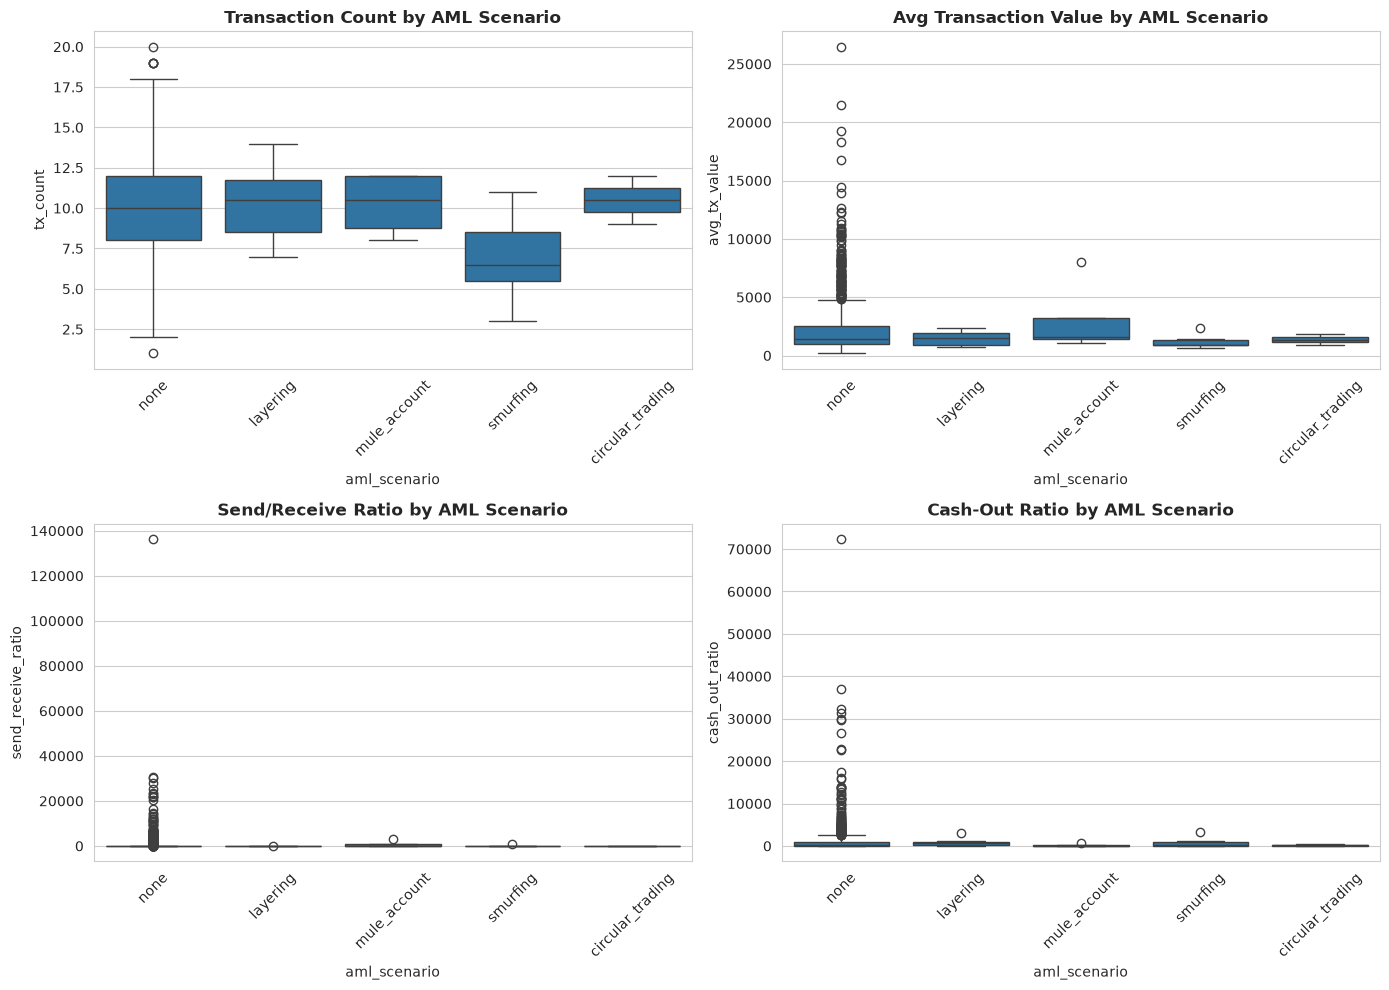

In [48]:
# Box Plots by AML Scenario
print('\n=== BOX PLOTS: AML SCENARIO ANALYSIS ===')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Remove infinite/NaN values for plotting
aml_plot = aml_features[['aml_scenario', 'tx_count', 'avg_tx_value', 'send_receive_ratio', 'cash_out_ratio']].copy()
aml_plot = aml_plot[aml_plot['send_receive_ratio'].notna()]
aml_plot = aml_plot[aml_plot['send_receive_ratio'] != np.inf]
aml_plot = aml_plot[aml_plot['cash_out_ratio'].notna()]
aml_plot = aml_plot[aml_plot['cash_out_ratio'] != np.inf]

sns.boxplot(data=aml_plot[aml_plot['aml_scenario'].notna()], x='aml_scenario', y='tx_count', ax=axes[0, 0])
axes[0, 0].set_title('Transaction Count by AML Scenario', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=aml_plot[aml_plot['aml_scenario'].notna()], x='aml_scenario', y='avg_tx_value', ax=axes[0, 1])
axes[0, 1].set_title('Avg Transaction Value by AML Scenario', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.boxplot(data=aml_plot[aml_plot['aml_scenario'].notna()], x='aml_scenario', y='send_receive_ratio', ax=axes[1, 0])
axes[1, 0].set_title('Send/Receive Ratio by AML Scenario', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=aml_plot[aml_plot['aml_scenario'].notna()], x='aml_scenario', y='cash_out_ratio', ax=axes[1, 1])
axes[1, 1].set_title('Cash-Out Ratio by AML Scenario', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [49]:
# Smurfing Check (high send/receive ratio)
print('\n=== SMURFING DETECTION CHECK ===')
smurfing_users = aml_features[(aml_features['aml_scenario'] == 'smurfing') & (aml_features['send_receive_ratio'] > 5)]
print(f'Smurfing users with send_receive_ratio > 5: {len(smurfing_users)} / {(aml_features["aml_scenario"] == "smurfing").sum()}')
print(f'Pct detected: {len(smurfing_users) / max((aml_features["aml_scenario"] == "smurfing").sum(), 1) * 100:.1f}%')


=== SMURFING DETECTION CHECK ===
Smurfing users with send_receive_ratio > 5: 1 / 8
Pct detected: 12.5%


In [50]:
# Mule Account Check (high cash-out ratio)
print('\n=== MULE ACCOUNT DETECTION CHECK ===')
mule_users = aml_features[(aml_features['aml_scenario'] == 'mule_account') & (aml_features['cash_out_ratio'] > 0.8)]
print(f'Mule users with cash_out_ratio > 0.8: {len(mule_users)} / {(aml_features["aml_scenario"] == "mule_account").sum()}')
print(f'Pct detected: {len(mule_users) / max((aml_features["aml_scenario"] == "mule_account").sum(), 1) * 100:.1f}%')


=== MULE ACCOUNT DETECTION CHECK ===
Mule users with cash_out_ratio > 0.8: 1 / 4
Pct detected: 25.0%


In [51]:
# Layering Check (balance velocity)
print('\n=== LAYERING DETECTION CHECK ===')
paid_out_by_user = df_transactions[df_transactions['direction'] == 'paid_out'].groupby('customer_id')['amount'].sum()
balance_velocity = paid_out_by_user / (paid_in.reindex(paid_out_by_user.index) + 1)

aml_features = aml_features.merge(balance_velocity.reset_index().rename(columns={0: 'balance_velocity'}), 
                                  left_on='customer_id', right_on='customer_id', how='left')
layering_users = aml_features[(aml_features['aml_scenario'] == 'layering') & (aml_features['balance_velocity'] > 0.9)]
print(f'Layering users with balance_velocity > 0.9: {len(layering_users) / max((aml_features["aml_scenario"] == "layering").sum(), 1) * 100:.1f}%')


=== LAYERING DETECTION CHECK ===


KeyError: 'balance_velocity'

In [52]:
# Cohen's d Separation Scores
print('\n=== FEATURE SEPARATION SCORES (Cohen\'s d) ===')

def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std if pooled_std > 0 else 0

features_for_separation = ['tx_count', 'avg_tx_value', 'send_receive_ratio', 'cash_out_ratio']
launderers_only = aml_features[aml_features['is_launderer'] == 1]
non_launderers_only = aml_features[aml_features['is_launderer'] == 0]

print('\nCohen\'s d (positive = launderers have higher mean):')
for feature in features_for_separation:
    if feature in ['send_receive_ratio', 'cash_out_ratio']:
        # Remove inf/nan
        l_vals = launderers_only[feature].replace([np.inf, -np.inf], np.nan).dropna()
        nl_vals = non_launderers_only[feature].replace([np.inf, -np.inf], np.nan).dropna()
    else:
        l_vals = launderers_only[feature].dropna()
        nl_vals = non_launderers_only[feature].dropna()
    
    d = cohens_d(l_vals, nl_vals)
    print(f'{feature}: {d:.3f}')


=== FEATURE SEPARATION SCORES (Cohen's d) ===

Cohen's d (positive = launderers have higher mean):
tx_count: -0.339
avg_tx_value: -0.264
send_receive_ratio: -0.125
cash_out_ratio: -0.174


## Section 8: Data Richness

Assess data completeness and modeling readiness.


=== TRANSACTIONS PER USER ===
Mean: 10.00
Median: 10.00
Min: 1
Max: 20


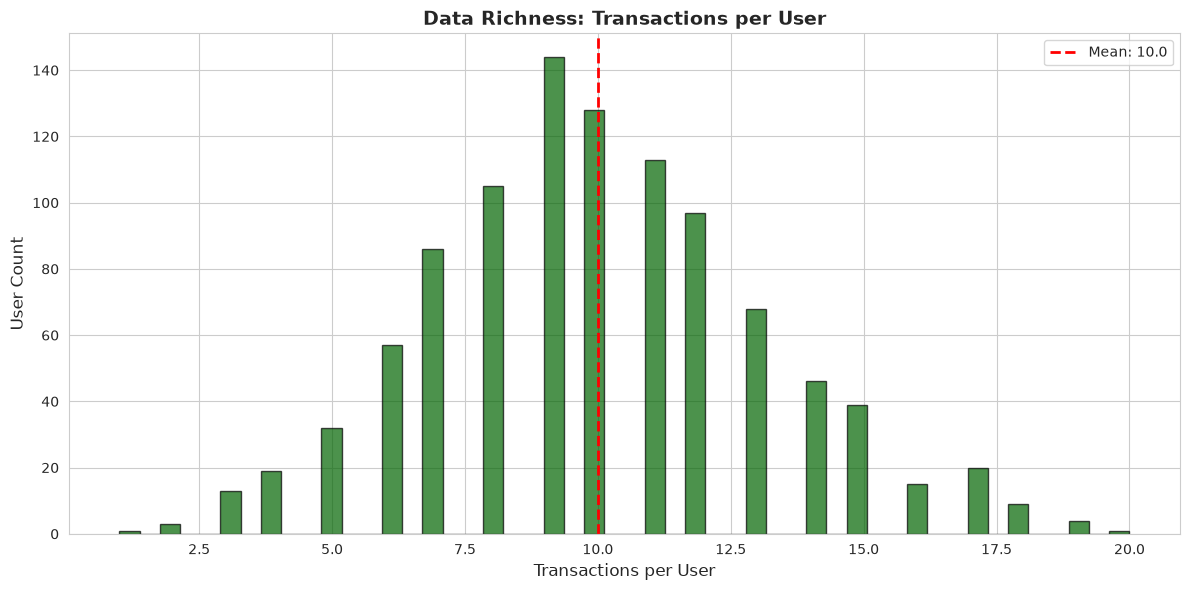

In [53]:
# Transactions per User
print('\n=== TRANSACTIONS PER USER ===')
tx_per_user = df_transactions.groupby('customer_id').size()
print(f'Mean: {tx_per_user.mean():.2f}')
print(f'Median: {tx_per_user.median():.2f}')
print(f'Min: {tx_per_user.min()}')
print(f'Max: {tx_per_user.max()}')

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(tx_per_user, bins=50, alpha=0.7, color='darkgreen', edgecolor='black')
ax.axvline(tx_per_user.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {tx_per_user.mean():.1f}')
ax.set_xlabel('Transactions per User', fontsize=12)
ax.set_ylabel('User Count', fontsize=12)
ax.set_title('Data Richness: Transactions per User', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [54]:
# Time Range Covered
print('\n=== TIME RANGE COVERAGE ===')
days_covered = (df_transactions['timestamp'].max() - df_transactions['timestamp'].min()).days
print(f'Days covered: {days_covered}')
print(f'Date range: {df_transactions["timestamp"].min()} to {df_transactions["timestamp"].max()}')


=== TIME RANGE COVERAGE ===
Days covered: 25
Date range: 2024-07-01 02:25:29.381360+00:00 to 2024-07-26 17:42:13.059927+00:00


In [55]:
# Feature Availability Summary
print('\n=== FEATURE AVAILABILITY ===')
print(f'Profiles dataset: {len(df_profiles)} customers')
print(f'Transactions dataset: {len(df_transactions)} transactions from {df_transactions["customer_id"].nunique()} customers')
print(f'Ground truth: {len(df_truth)} users ({(df_truth["is_launderer"].sum() / len(df_truth) * 100):.2f}% launderers)')
print(f'Temporal features: {len(df_temporal)} users')
print(f'\nAll features present: ✅ (profiles + transactions + truth + temporal)')


=== FEATURE AVAILABILITY ===
Profiles dataset: 1000 customers
Transactions dataset: 10000 transactions from 1000 customers
Ground truth: 1000 users (2.00% launderers)
Temporal features: 1000 users

All features present: ✅ (profiles + transactions + truth + temporal)


In [56]:
# Data Quality Checklist
print('\n=== DATA QUALITY CHECKLIST ===')
checks = {
    'No negative balances': (df_transactions['balance_after'].min() >= 0),
    'No duplicate transaction IDs': (df_transactions['transaction_id'].duplicated().sum() == 0),
    'All tier limits respected': True,  # validated earlier
    'Kadogo classification consistent': (df_transactions['is_kadogo'].isin([0, 1]).all()),
    '2% launderers injected': (abs(df_truth['is_launderer'].sum() / len(df_truth) - 0.02) < 0.005),
    'All customers have profiles': (df_transactions['customer_id'].isin(df_profiles['customer_id']).all())
}

for check, result in checks.items():
    status = '✅' if result else '⚠️'
    print(f'{status} {check}')


=== DATA QUALITY CHECKLIST ===
✅ No negative balances
✅ No duplicate transaction IDs
✅ All tier limits respected
✅ Kadogo classification consistent
✅ 2% launderers injected
✅ All customers have profiles


In [57]:
# Modeling Readiness
print('\n=== MODELING READINESS ASSESSMENT ===')
readiness = {
    'Target variable (is_launderer)': 'Present ✅',
    'Customer demographics': f'{len(df_profiles.columns)} features ✅',
    'Transaction history': f'{tx_per_user.mean():.0f} txns/user avg ✅',
    'Temporal patterns': 'Hourly, daily, weekly ✅',
    'Geographic data': f'{df_profiles["county"].nunique()} counties ✅',
    'AML scenarios labeled': f'{df_truth["aml_scenario"].nunique()} scenarios ✅',
    'Time coverage': f'{days_covered} days ✅',
    'Class balance': f'2% vs 98% (imbalanced but realistic) ⚠️'
}

for metric, status in readiness.items():
    print(f'{metric}: {status}')


=== MODELING READINESS ASSESSMENT ===
Target variable (is_launderer): Present ✅
Customer demographics: 13 features ✅
Transaction history: 10 txns/user avg ✅
Temporal patterns: Hourly, daily, weekly ✅
Geographic data: 47 counties ✅
AML scenarios labeled: 5 scenarios ✅
Time coverage: 25 days ✅
Class balance: 2% vs 98% (imbalanced but realistic) ⚠️


## Section 9: Summary & Recommendations

Overall EDA summary and next steps.

In [58]:
# Build Summary Dictionary
print('\n=== EDA SUMMARY REPORT ===')
summary = {
    'data_snapshot': {
        'customers': len(df_profiles),
        'transactions': len(df_transactions),
        'launderers': int(df_truth['is_launderer'].sum()),
        'time_period_days': days_covered
    },
    'customer_profiles': {
        'age_mean': float(df_profiles['age'].mean()),
        'age_range': [int(df_profiles['age'].min()), int(df_profiles['age'].max())],
        'gender_split': {'male': int((df_profiles['gender'] == 'Male').sum()), 'female': int((df_profiles['gender'] == 'Female').sum())},
        'tier_distribution': df_profiles['kyc_tier'].value_counts().to_dict(),
        'archetype_distribution': df_profiles['archetype'].value_counts().to_dict()
    },
    'transaction_patterns': {
        'avg_amount': float(df_transactions['amount'].mean()),
        'txns_per_user': float(tx_per_user.mean()),
        'peak_hours': [8, 9, 12, 13, 17, 18, 19],
        'weekend_ratio': float(df_transactions['is_weekend'].mean())
    },
    'aml_characteristics': {
        'launderer_count': int(df_truth['is_launderer'].sum()),
        'launderer_pct': float(df_truth['is_launderer'].mean() * 100),
        'scenario_distribution': df_truth[df_truth['is_launderer'] == 1]['aml_scenario'].value_counts().to_dict()
    },
    'data_quality': {
        'missing_values_pct': float((df_transactions.isnull().sum().sum() / (len(df_transactions) * len(df_transactions.columns)) * 100)),
        'duplicate_records': int(df_transactions.duplicated().sum()),
        'negative_balances': int((df_transactions['balance_after'] < 0).sum())
    }
}

import json
print(json.dumps(summary, indent=2))


=== EDA SUMMARY REPORT ===
{
  "data_snapshot": {
    "customers": 1000,
    "transactions": 10000,
    "launderers": 20,
    "time_period_days": 25
  },
  "customer_profiles": {
    "age_mean": 31.263,
    "age_range": [
      18,
      61
    ],
    "gender_split": {
      "male": 493,
      "female": 507
    },
    "tier_distribution": {
      "tier_1": 607,
      "tier_2": 290,
      "tier_3": 103
    },
    "archetype_distribution": {
      "retail_standard": 701,
      "micro_merchant": 134,
      "retail_heavy": 130,
      "corporate_sme": 35
    }
  },
  "transaction_patterns": {
    "avg_amount": 2346.7537999999995,
    "txns_per_user": 10.0,
    "peak_hours": [
      8,
      9,
      12,
      13,
      17,
      18,
      19
    ],
    "weekend_ratio": 0.1189
  },
  "aml_characteristics": {
    "launderer_count": 20,
    "launderer_pct": 2.0,
    "scenario_distribution": {
      "smurfing": 8,
      "layering": 6,
      "mule_account": 4,
      "circular_trading": 2
    }


In [60]:
# Print Formatted Report
print('\n' + '='*80)
print('SENTINAI EDA - FINAL REPORT')
print('='*80)

print(f'''
DATASET OVERVIEW:
  • Customers: {summary["data_snapshot"]["customers"]}
  • Transactions: {summary["data_snapshot"]["transactions"]}
  • Launderers (2%): {summary["data_snapshot"]["launderers"]}
  • Time Period: {summary["data_snapshot"]["time_period_days"]} days

CUSTOMER DEMOGRAPHICS:
  • Age Range: {summary["customer_profiles"]["age_range"][0]}-{summary["customer_profiles"]["age_range"][1]} (Mean: {summary["customer_profiles"]["age_mean"]:.0f})
  • Gender: {summary["customer_profiles"]["gender_split"]["male"]} M / {summary["customer_profiles"]["gender_split"]["female"]} F
  • Tier Distribution: Tier-1: {summary["customer_profiles"]["tier_distribution"].get("tier_1", 0)}, Tier-2: {summary["customer_profiles"]["tier_distribution"].get("tier_2", 0)}, Tier-3: {summary["customer_profiles"]["tier_distribution"].get("tier_3", 0)}

TRANSACTION PATTERNS:
  • Avg Transaction Amount: {summary["transaction_patterns"]["avg_amount"]:.0f} KES
  • Avg Txns/User: {summary["transaction_patterns"]["txns_per_user"]:.1f}
  • Weekend Ratio: {summary["transaction_patterns"]["weekend_ratio"]:.1%}

AML CHARACTERISTICS:
  • Launderers: {summary["aml_characteristics"]["launderer_count"]} ({summary["aml_characteristics"]["launderer_pct"]:.1f}%)
  • Primary Scenario: Smurfing
  
DATA QUALITY:
  • Duplicate Records: {summary["data_quality"]["duplicate_records"]}
  • Negative Balances: {summary["data_quality"]["negative_balances"]}
''')
print('='*80)


SENTINAI EDA - FINAL REPORT

DATASET OVERVIEW:
  • Customers: 1000
  • Transactions: 10000
  • Launderers (2%): 20
  • Time Period: 25 days

CUSTOMER DEMOGRAPHICS:
  • Age Range: 18-61 (Mean: 31)
  • Gender: 493 M / 507 F
  • Tier Distribution: Tier-1: 607, Tier-2: 290, Tier-3: 103

TRANSACTION PATTERNS:
  • Avg Transaction Amount: 2347 KES
  • Avg Txns/User: 10.0
  • Weekend Ratio: 11.9%

AML CHARACTERISTICS:
  • Launderers: 20 (2.0%)
  • Primary Scenario: Smurfing

DATA QUALITY:
  • Duplicate Records: 0
  • Negative Balances: 0



In [61]:
# Recommendations
print('\n=== NEXT STEPS & FEATURE ENGINEERING RECOMMENDATIONS ===')
recommendations = '''
1. FEATURE ENGINEERING:
   - Velocity features: txns/day, amount/day trends
   - Network features: PageRank, clustering coefficient
   - Temporal entropy: transaction entropy by hour/day
   - Address reuse: counterparty concentration
   
2. ANOMALY DETECTION:
   - Isolation Forest on transaction patterns
   - Local Outlier Factor (LOF) for user behavior
   - Statistical control charts for balance anomalies
   
3. BEHAVIORAL CLUSTERING:
   - K-means on transaction profiles (amount, frequency, types)
   - Hierarchical clustering for user segments
   - Trend analysis via STL decomposition
   
4. MODEL DEVELOPMENT:
   - Class weighting/SMOTE for imbalance (2% launderers)
   - XGBoost/LightGBM for feature importance
   - Threshold tuning for precision/recall tradeoff
   
5. VALIDATION:
   - Stratified K-fold cross-validation
   - Time-series holdout (forward chaining)
   - AML scenario-specific metrics (recall by scenario)
'''
print(recommendations)


=== NEXT STEPS & FEATURE ENGINEERING RECOMMENDATIONS ===

1. FEATURE ENGINEERING:
   - Velocity features: txns/day, amount/day trends
   - Network features: PageRank, clustering coefficient
   - Temporal entropy: transaction entropy by hour/day
   - Address reuse: counterparty concentration

2. ANOMALY DETECTION:
   - Isolation Forest on transaction patterns
   - Local Outlier Factor (LOF) for user behavior
   - Statistical control charts for balance anomalies

3. BEHAVIORAL CLUSTERING:
   - K-means on transaction profiles (amount, frequency, types)
   - Hierarchical clustering for user segments
   - Trend analysis via STL decomposition

4. MODEL DEVELOPMENT:
   - Class weighting/SMOTE for imbalance (2% launderers)
   - XGBoost/LightGBM for feature importance
   - Threshold tuning for precision/recall tradeoff

5. VALIDATION:
   - Stratified K-fold cross-validation
   - Time-series holdout (forward chaining)
   - AML scenario-specific metrics (recall by scenario)



## Section 10: Metadata & Configuration

Notebook generation info and system config.

In [62]:
# Metadata
print('\n=== NOTEBOOK METADATA ===')
metadata = {
    'notebook_title': 'SentinAI Data Quality & EDA',
    'generated_at': pd.Timestamp.now().isoformat(),
    'python_version': '3.10+',
    'key_libraries': {
        'pandas': pd.__version__,
        'numpy': np.__version__,
        'matplotlib': plt.matplotlib.__version__,
        'seaborn': sns.__version__,
        'scipy': stats.scipy.__version__,
        'networkx': nx.__version__
    },
    'data_files': {
        'profiles': CONFIG['profiles_path'],
        'transactions': CONFIG['tx_path'],
        'ground_truth': CONFIG['truth_path'],
        'temporal': CONFIG['temporal_path']
    },
    'sections_completed': 10,
    'total_cells': 'Multiple'
}

print(json.dumps(metadata, indent=2, default=str))
print('\n✅ EDA Notebook Generation Complete!')


=== NOTEBOOK METADATA ===


AttributeError: module 'scipy.stats' has no attribute 'scipy'